# PAMAP2: Comparación de métodos de tratamiento de datos faltantes

Se comparan los siguientes métodos:

- Linear interpolation
- Fill Foward
- Remover las filas donde haya faltantes

Actividades:
 - 1	lying
 - 2	sitting
 - 3	standing
 - 4	walking
 - 5	running
 - 6	cycling
 - 7	Nordic walking
 - 9	watching TV
 - 10	computer work
 - 11	car driving
 - 12	ascending stairs
 - 13	descending stairs
 - 16	vacuum cleaning
 - 17	ironing
 - 18	folding laundry
 - 19	house cleaning
 - 20	playing soccer
 - 24	rope jumping
 - 0	other (transient activities)

Sujetos: 9 sujetos

Frecuencia de muestreo:
- **IMU**: 100Hz
- **HR**: 9Hz

# 1    Cargar datos

Cargamos las librerías

In [1]:
import pandas as pd
import os

pd.set_option("display.float_format", "{:.3f}".format)

Definimos el cargador de datos

In [2]:
from abc import ABC, abstractmethod


# DEFINIMOS LA INTERFAZ DEL CARGADOR DE DATOS ---------------------------------------------------------------------------------------------
class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass

# CREAMOS EL CARGADOR DE DATOS PARA PAMAP2 ---------------------------------------------------------------------------------------------
class DataLoader(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for file in os.listdir(self.src_path):
            if self._is_valid_extension(file):  
                df = pd.read_csv(os.path.join(self.src_path, file), delimiter=self.delimiter, names=self.keys)
                df['subject_id'] = self._get_subject_id(file)
                dataframes.append(df)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df

                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)

    def _get_subject_id(self, file):
        return file.split('.')[0]

Definomos las columnas de los sensores y realizamos la carga

In [3]:
src = "dataset/PAMAP2/PAMAP2_Dataset/Protocol/"
keys = [
    "timestamp",
    "activityID",
    "heart_rate_bpm",
    # IMU Hand (columns 4–20)
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    # IMU Chest (columns 21–37)
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    # IMU Ankle (columns 38–54)
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

file_extension = '.dat'
delimiter = r'\s+'
data_loader_pamap = DataLoader(src, keys, file_extension, delimiter)
pamap_data = data_loader_pamap.load_data()

pamap_data.shape

(2872533, 55)

# 2 Tratamiento de datos irrelevantes

Eliminamos:
- Sujeto 9: no realiza todas las actividaes
- Label 0: representa actividades de transición

## 2.1 Eliminar el sujeto 9

Antes:
- 9 valores únicos que se corresponden con nuestros 9 sujetos
- queremos eliminar el sujeto 9 bajo el label "subject109"

In [20]:
pamap_data.subject_id.describe()

count        2872533
unique             9
top       subject102
freq          447000
Name: subject_id, dtype: object

In [21]:
pamap_data['subject_id'].unique()

array(['subject106', 'subject102', 'subject101', 'subject107',
       'subject103', 'subject104', 'subject108', 'subject109',
       'subject105'], dtype=object)

Eliminamos al sujeto 9

In [4]:
pamap_data = pamap_data[pamap_data['subject_id'] != "subject109" ]

Después:
- ahora solo hay 8 únicos
- el "subject109" ya no está

In [23]:
pamap_data.subject_id.describe()

count        2864056
unique             8
top       subject102
freq          447000
Name: subject_id, dtype: object

In [24]:
pamap_data['subject_id'].unique()

array(['subject106', 'subject102', 'subject101', 'subject107',
       'subject103', 'subject104', 'subject108', 'subject105'],
      dtype=object)

## 2.2 Eliminar la actividad de transición

Antes: 
- 13 actividades en total
- label 0 que representa transición

In [25]:
no_activities = len(pamap_data.activityID.unique())
labels_list = pamap_data.activityID.unique()

print(f"Number of unique activities: {no_activities}\n Activity labels: {labels_list}")

Number of unique activities: 13
 Activity labels: [ 0  1  2  3 17 16 12 13  4  7  6  5 24]


Eliminamos la actividad 0

In [5]:
pamap_data = pamap_data[pamap_data['activityID'] != 0]

Después:
- 12 actividades
- ya no hay 0

In [27]:
no_activities_post = len(pamap_data.activityID.unique())
labels_list_post = pamap_data.activityID.unique()

print(f"Number of unique activities: {no_activities_post}\n Activity labels: {labels_list_post}")

Number of unique activities: 12
 Activity labels: [ 1  2  3 17 16 12 13  4  7  6  5 24]


## 2.3 Filtrar columnas irrelevantes

Filtramos las columnas irrelevantes:
- 6g
- Orientation
- Heart Rate
- Temperature

In [6]:
irrelevant_columns = [
    # 6g
    'IMU_Hand_acceleration_6g_x',
    'IMU_Hand_acceleration_6g_y',
    'IMU_Hand_acceleration_6g_z',
    'IMU_Chest_acceleration_6g_x',
    'IMU_Chest_acceleration_6g_y',
    'IMU_Chest_acceleration_6g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    # orientation
    'IMU_Ankle_orientation_1',
    'IMU_Ankle_orientation_2',
    'IMU_Ankle_orientation_3',
    'IMU_Ankle_orientation_4',
    'IMU_Hand_orientation_1',
    'IMU_Hand_orientation_2',
    'IMU_Hand_orientation_3',
    'IMU_Hand_orientation_4',
    'IMU_Chest_orientation_1',
    'IMU_Chest_orientation_2',
    'IMU_Chest_orientation_3',
    'IMU_Chest_orientation_4',
    # heart rate
    'heart_rate_bpm', 
    # temperature
    'IMU_Hand_temperature',
    'IMU_Chest_temperature',
    'IMU_Ankle_temperature'
]

pamap_data_filtered = pamap_data.drop(columns=irrelevant_columns, errors='ignore')
pamap_data_filtered.isnull().sum()

timestamp                           0
activityID                          0
IMU_Hand_acceleration_16g_x     11122
IMU_Hand_acceleration_16g_y     11122
IMU_Hand_acceleration_16g_z     11122
IMU_Hand_gyroscope_x            11122
IMU_Hand_gyroscope_y            11122
IMU_Hand_gyroscope_z            11122
IMU_Hand_magnetometer_x         11122
IMU_Hand_magnetometer_y         11122
IMU_Hand_magnetometer_z         11122
IMU_Chest_acceleration_16g_x     2420
IMU_Chest_acceleration_16g_y     2420
IMU_Chest_acceleration_16g_z     2420
IMU_Chest_gyroscope_x            2420
IMU_Chest_gyroscope_y            2420
IMU_Chest_gyroscope_z            2420
IMU_Chest_magnetometer_x         2420
IMU_Chest_magnetometer_y         2420
IMU_Chest_magnetometer_z         2420
IMU_Ankle_acceleration_16g_x     8504
IMU_Ankle_acceleration_16g_y     8504
IMU_Ankle_acceleration_16g_z     8504
IMU_Ankle_gyroscope_x            8504
IMU_Ankle_gyroscope_y            8504
IMU_Ankle_gyroscope_z            8504
IMU_Ankle_ma

# 3. Datos Faltantes

En total hay 198,414 datos faltantes

In [29]:
pamap_data_filtered.isna().sum().sum()

np.int64(198414)

Vemos que el patrón es la parte del cuerpo en la que el sensor está puesto

In [30]:
pamap_data_filtered.isnull().sum()

timestamp                           0
activityID                          0
IMU_Hand_acceleration_16g_x     11122
IMU_Hand_acceleration_16g_y     11122
IMU_Hand_acceleration_16g_z     11122
IMU_Hand_gyroscope_x            11122
IMU_Hand_gyroscope_y            11122
IMU_Hand_gyroscope_z            11122
IMU_Hand_magnetometer_x         11122
IMU_Hand_magnetometer_y         11122
IMU_Hand_magnetometer_z         11122
IMU_Chest_acceleration_16g_x     2420
IMU_Chest_acceleration_16g_y     2420
IMU_Chest_acceleration_16g_z     2420
IMU_Chest_gyroscope_x            2420
IMU_Chest_gyroscope_y            2420
IMU_Chest_gyroscope_z            2420
IMU_Chest_magnetometer_x         2420
IMU_Chest_magnetometer_y         2420
IMU_Chest_magnetometer_z         2420
IMU_Ankle_acceleration_16g_x     8504
IMU_Ankle_acceleration_16g_y     8504
IMU_Ankle_acceleration_16g_z     8504
IMU_Ankle_gyroscope_x            8504
IMU_Ankle_gyroscope_y            8504
IMU_Ankle_gyroscope_z            8504
IMU_Ankle_ma

Los faltantes por parte del cuerpo son:

In [31]:
# Definir las partes del cuerpo
body_parts = ['Hand', 'Chest', 'Ankle']

# Calcular cuántas filas tienen al menos un valor faltante por parte del cuerpo
missing_rows_by_part = {
    part: pamap_data_filtered.filter(regex=part).isnull().any(axis=1).sum()
    for part in body_parts
}

# Imprimir los resultados
print("Cantidad de filas con al menos un valor faltante por parte del cuerpo:")
for part, count in missing_rows_by_part.items():
    print(f"{part}: {count}")


Cantidad de filas con al menos un valor faltante por parte del cuerpo:
Hand: 11122
Chest: 2420
Ankle: 8504


El que más le falta es la mano, seguido del tobillo y finalmente el torso

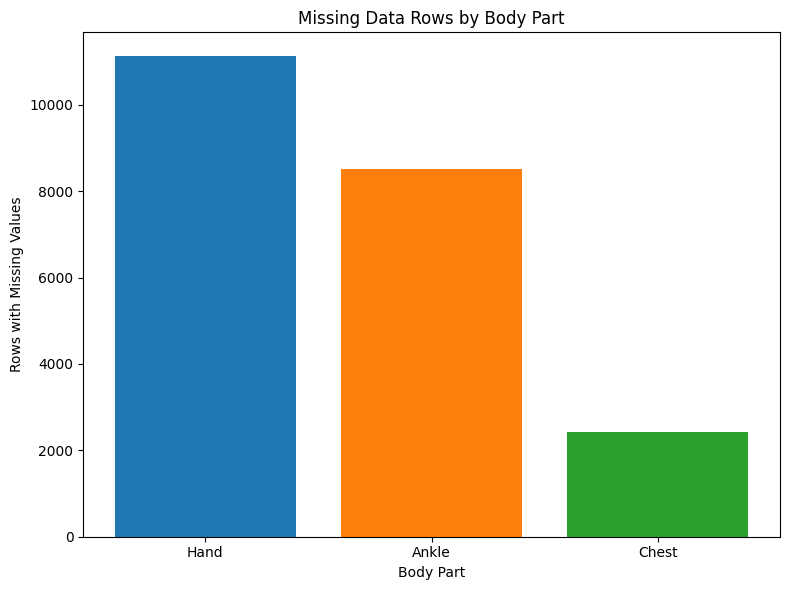

In [33]:
import matplotlib.pyplot as plt

# Sort the data in descending order by value
sorted_items = sorted(missing_rows_by_part.items(), key=lambda x: x[1], reverse=True)
body_parts = [item[0] for item in sorted_items]
missing_values = [item[1] for item in sorted_items]

# Create the figure
plt.figure(figsize=(8, 6))

# Draw the bars one by one with default colors
for i in range(len(body_parts)):
    plt.bar(body_parts[i], missing_values[i])  # Matplotlib assigns default colors automatically

plt.xlabel("Body Part")
plt.ylabel("Rows with Missing Values")
plt.title("Missing Data Rows by Body Part")
plt.xticks()
plt.tight_layout()
plt.show()


En comparación con todas las filas que se tienen, en realidad el porcentaje de faltantes incluso del que más faltantes tiene es despreciable (menos de 1%). Esto dado que tenemos 1,936,481 de filas en el dataset, y las faltantes de la mano son solo 11,122. Esto es exactamente 0.574%, ni siquiera un 0.6%. Las demás son incluso menores. 

In [34]:
import pandas as pd

# Definir las partes del cuerpo
body_parts = ['Hand', 'Chest', 'Ankle']

# Calcular cuántas filas tienen al menos un valor faltante por parte del cuerpo
missing_rows_by_part = {
    part: pamap_data_filtered.filter(regex=part).isnull().any(axis=1).sum()
    for part in body_parts
}

# Calcular el total de filas en el dataset
total_rows = pamap_data_filtered.shape[0]

# Calcular el ratio de faltantes y el porcentaje de faltantes
ratios = {part: count / total_rows for part, count in missing_rows_by_part.items()}
porcentajes = {part: ratio * 100 for part, ratio in ratios.items()}

# Crear el DataFrame con los resultados
missing_data_by_part = pd.DataFrame({
    'Body Part': list(missing_rows_by_part.keys()),
    'Missing Rows': list(missing_rows_by_part.values()),
    'Missing Percentage': list(porcentajes.values())
})

# Ordenar el DataFrame por 'Missing Rows' de mayor a menor y resetear el índice sin mantener el original
missing_data_by_part = missing_data_by_part.sort_values(by='Missing Rows', ascending=False).reset_index(drop=True)

# Imprimir el total de filas y el DataFrame ordenado sin el índice original
print(f"Total de filas en el dataset: {total_rows}")
print("\nMissing Data by Body Part:")
missing_data_by_part

Total de filas en el dataset: 1936481

Missing Data by Body Part:


,Body Part,Missing Rows,Missing Percentage
0,Hand,11122,0.574
1,Ankle,8504,0.439
2,Chest,2420,0.125


# T2 Eliminación de datos, NO UTILIZAR

## T2.1 Drop NA

In [166]:
deep_copy_pamap = pamap_data_filtered.copy().infer_objects()
deep_copy_pamap.columns

Index(['timestamp', 'activityID', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'subject_id'],
      dtype='object')

In [167]:
deep_copy_pamap.head()

,timestamp,activityID,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,...,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,subject_id
2928,37.660,1,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,-67.933,...,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,subject101
2929,37.670,1,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,-67.958,...,9.698,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366,subject101
2930,37.680,1,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,-67.402,...,9.696,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612,subject101
2931,37.690,1,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,-67.439,...,9.664,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880,subject101
2932,37.700,1,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,-67.183,...,9.776,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885,subject101


In [168]:
non_sensor_cols = ['timestamp', 'activityID', 'subject_id']

sensor_cols = [col for col in deep_copy_pamap.columns if col not in non_sensor_cols]

pamap_na_dropped = deep_copy_pamap.dropna(subset=sensor_cols)
pamap_na_dropped.shape

(1915045, 30)

In [169]:
pamap_na_dropped.head()

,timestamp,activityID,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,...,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,subject_id
2928,37.660,1,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,-67.933,...,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,subject101
2929,37.670,1,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,-67.958,...,9.698,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366,subject101
2930,37.680,1,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,-67.402,...,9.696,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612,subject101
2931,37.690,1,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,-67.439,...,9.664,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880,subject101
2932,37.700,1,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,-67.183,...,9.776,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885,subject101


In [170]:
pamap_na_dropped.dtypes

timestamp                       float64
activityID                        int64
IMU_Hand_acceleration_16g_x     float64
IMU_Hand_acceleration_16g_y     float64
IMU_Hand_acceleration_16g_z     float64
IMU_Hand_gyroscope_x            float64
IMU_Hand_gyroscope_y            float64
IMU_Hand_gyroscope_z            float64
IMU_Hand_magnetometer_x         float64
IMU_Hand_magnetometer_y         float64
IMU_Hand_magnetometer_z         float64
IMU_Chest_acceleration_16g_x    float64
IMU_Chest_acceleration_16g_y    float64
IMU_Chest_acceleration_16g_z    float64
IMU_Chest_gyroscope_x           float64
IMU_Chest_gyroscope_y           float64
IMU_Chest_gyroscope_z           float64
IMU_Chest_magnetometer_x        float64
IMU_Chest_magnetometer_y        float64
IMU_Chest_magnetometer_z        float64
IMU_Ankle_acceleration_16g_x    float64
IMU_Ankle_acceleration_16g_y    float64
IMU_Ankle_acceleration_16g_z    float64
IMU_Ankle_gyroscope_x           float64
IMU_Ankle_gyroscope_y           float64


In [171]:
pamap_na_dropped.isnull().sum()

timestamp                       0
activityID                      0
IMU_Hand_acceleration_16g_x     0
IMU_Hand_acceleration_16g_y     0
IMU_Hand_acceleration_16g_z     0
IMU_Hand_gyroscope_x            0
IMU_Hand_gyroscope_y            0
IMU_Hand_gyroscope_z            0
IMU_Hand_magnetometer_x         0
IMU_Hand_magnetometer_y         0
IMU_Hand_magnetometer_z         0
IMU_Chest_acceleration_16g_x    0
IMU_Chest_acceleration_16g_y    0
IMU_Chest_acceleration_16g_z    0
IMU_Chest_gyroscope_x           0
IMU_Chest_gyroscope_y           0
IMU_Chest_gyroscope_z           0
IMU_Chest_magnetometer_x        0
IMU_Chest_magnetometer_y        0
IMU_Chest_magnetometer_z        0
IMU_Ankle_acceleration_16g_x    0
IMU_Ankle_acceleration_16g_y    0
IMU_Ankle_acceleration_16g_z    0
IMU_Ankle_gyroscope_x           0
IMU_Ankle_gyroscope_y           0
IMU_Ankle_gyroscope_z           0
IMU_Ankle_magnetometer_x        0
IMU_Ankle_magnetometer_y        0
IMU_Ankle_magnetometer_z        0
subject_id    

## T2.2 Median Filter

In [173]:
from scipy.ndimage import median_filter
import pandas as pd

def medianify_dataframe(df, exclude_columns=None, filter_size=3):
    if exclude_columns is None:
        exclude_columns = []

    df_copy = df.copy()
    columns_for_filter = df.columns.difference(exclude_columns)

    df_filtered = df_copy[columns_for_filter].apply(lambda col: median_filter(col, size=filter_size))
    df_final = pd.concat([df_copy[exclude_columns], df_filtered], axis=1)

    return df_final[df.columns]

In [174]:
pamap_nadroped_median = medianify_dataframe(pamap_na_dropped, 
                                 exclude_columns=['activityID', 'subject_id', 'timestamp'], 
                                 filter_size=3)
pamap_nadroped_median.head()

,timestamp,activityID,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,...,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,subject_id
2928,37.660,1,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,-67.933,...,9.739,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,subject101
2929,37.670,1,2.291,7.673,5.745,-0.172,0.025,-0.010,9.055,-67.933,...,9.698,-1.884,-0.021,0.003,-0.028,0.002,-60.892,-36.320,-58.370,subject101
2930,37.680,1,2.291,7.144,5.823,-0.193,0.019,0.001,9.583,-67.439,...,9.696,-1.884,-0.021,-0.033,-0.019,0.006,-60.765,-36.320,-58.366,subject101
2931,37.690,1,2.291,7.144,5.899,-0.193,0.011,0.005,9.156,-67.402,...,9.696,-1.886,0.094,-0.033,-0.049,-0.005,-60.341,-37.103,-57.885,subject101
2932,37.700,1,2.218,7.259,6.012,-0.070,0.007,0.013,9.156,-67.183,...,9.664,-1.886,0.094,0.001,-0.027,0.004,-60.765,-37.103,-57.880,subject101


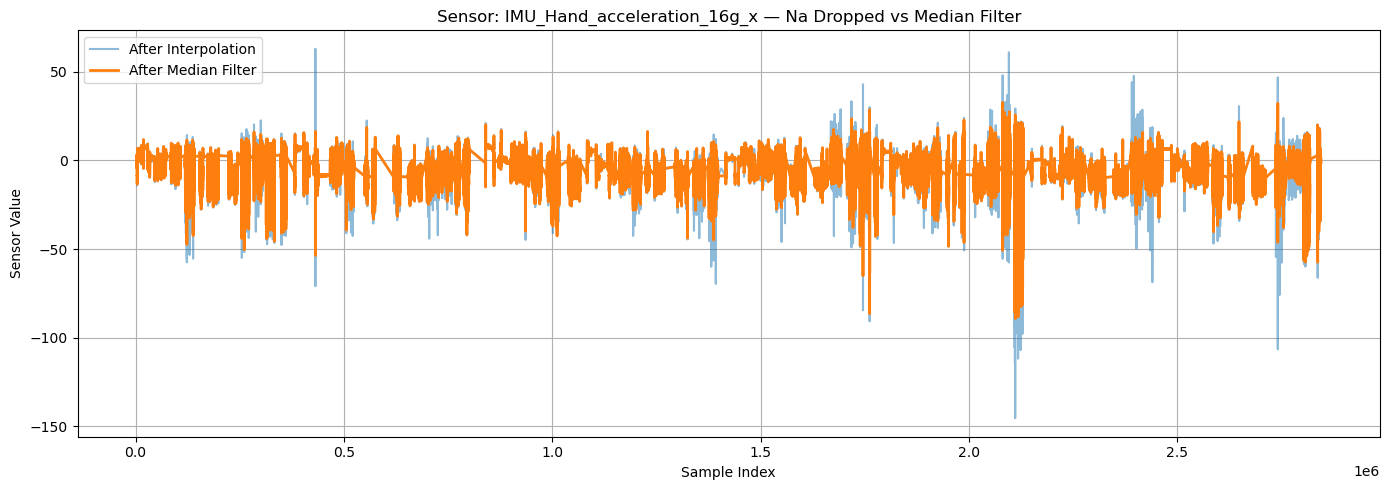

In [175]:
import matplotlib.pyplot as plt

# Choose a sensor column to visualize
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Extract signals
original = interpolated_df[sensor_column]
medianed = pamap_nadroped_median[sensor_column]

# Plot comparison
plt.figure(figsize=(14, 5))
plt.plot(original, label='After Interpolation', alpha=0.5)
plt.plot(medianed, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — Na Dropped vs Median Filter')
plt.xlabel('Sample Index')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

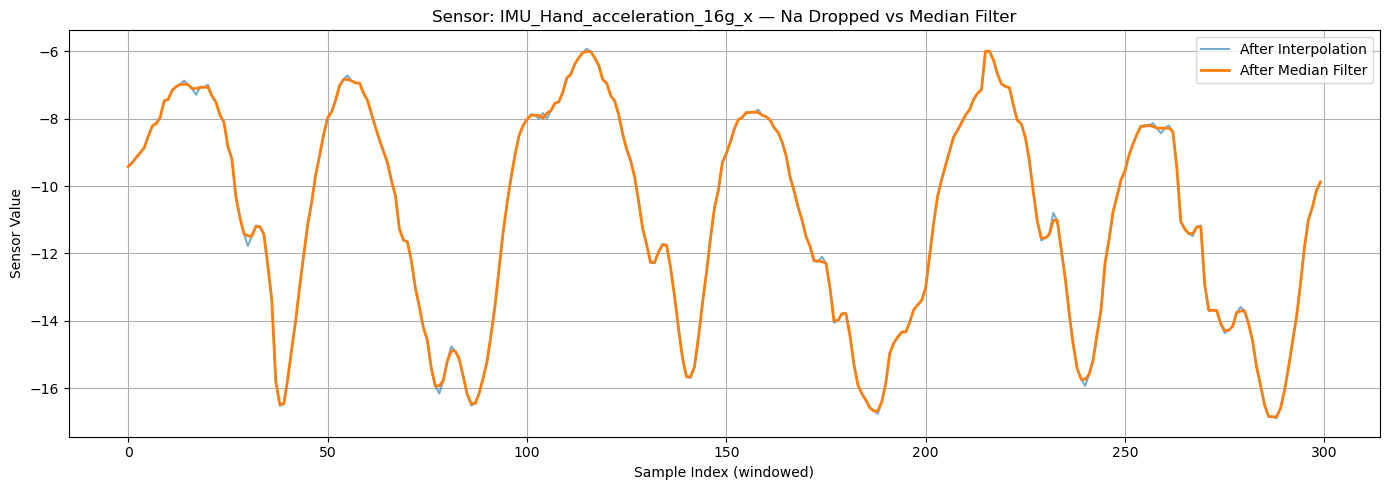

In [176]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the sensor column
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Total number of samples available
total_samples = len(pamap_nadroped_median)

# Choose random starting index such that we can take 300 samples without going out of bounds
start_idx = np.random.randint(0, total_samples - 300)

# Slice the 300-sample window
original = pamap_na_dropped[sensor_column].iloc[start_idx:start_idx + 300]
medianed = pamap_nadroped_median[sensor_column].iloc[start_idx:start_idx + 300]

# Plot
plt.figure(figsize=(14, 5))
plt.plot(original.values, label='After Interpolation', alpha=0.6)
plt.plot(medianed.values, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — Na Dropped vs Median Filter')
plt.xlabel('Sample Index (windowed)')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## T2.3 Segmentación

In [178]:
import pandas as pd

def segment_by_window(group, window_size):
    """
    Segments data into windows of specified size.

    Args:
        group (pd.DataFrame): Subject's data.
        window_size (int): Size of each time window.

    Returns:
        list: List of DataFrames, each representing a window of data.
    """
    windows = []
    for start in range(0, len(group), window_size):
        end = start + window_size
        if end <= len(group):
            window = group.iloc[start:end].copy()
            windows.append(window)
    return windows

def add_window_metadata(windows, subject_id):
    """
    Adds metadata like window number, window ID, and majority label.

    Args:
        windows (list): List of window DataFrames.
        subject_id (int): Subject identifier.

    Returns:
        list: List of windows with added metadata.
    """
    for i, window in enumerate(windows):
        window['subject_id'] = subject_id
        window['window_number'] = i
        window['window_id'] = f"{subject_id}_{window['window_number'].iloc[0]}"

        majority_label = get_majority_label(window)
        window['labels_in_window'] = [majority_label] * len(window)
    return windows

def get_majority_label(window):
    """
    Gets the majority label for a window.

    Args:
        window (pd.DataFrame): Window data.

    Returns:
        str: Majority label, or None if no majority.
    """
    label_counts = window['activityID'].value_counts()
    majority_label = label_counts.idxmax() if label_counts.max() / len(window) > 0.5 else window['label'].iloc[0]
    return majority_label

def process_subject_data(mhealth_df, window_size):
    """
    Processes all subject data by segmenting and adding metadata.

    Args:
        mhealth_df (pd.DataFrame): Data of multiple subjects.
        window_size (int): Size of each time window.

    Returns:
        list: List of windows with metadata.
    """
    all_windows = []
    for subject_id, group in mhealth_df.groupby('subject_id'):
        group = group.reset_index(drop=True)

        windows = segment_by_window(group, window_size)
        windows = add_window_metadata(windows, subject_id)
        all_windows.extend(windows)
    
    return all_windows

def concatenate_windows(windows):
    """
    Concatenates all windows into a single DataFrame.

    Args:
        windows (list): List of window DataFrames.

    Returns:
        pd.DataFrame: Concatenated DataFrame of all windows.
    """
    return pd.concat(windows).reset_index(drop=True)

def display_basic_info(ventanas_df, windows):
    """
    Displays basic info about windows and their majority labels.

    Args:
        ventanas_df (pd.DataFrame): DataFrame of windows with metadata.
        windows (list): List of processed windows.
    """
    for window_id, group in ventanas_df.groupby('window_id'):
        majority_label = group['labels_in_window'].iloc[0]

# Parameters
window_size = 300  # 3 seconds * 100 Hz

print(pamap_nadroped_median.shape)
windows = process_subject_data(pamap_nadroped_median, window_size)

# Concatenate all windows into a single DataFrame
pamap_windowed_nadropped = concatenate_windows(windows)

(1915045, 30)


In [179]:
pamap_windowed_nadropped.head()

,timestamp,activityID,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,...,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,subject_id,window_number,window_id,labels_in_window
0,37.660,1,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,-67.933,...,0.003,-0.028,0.002,-61.108,-36.864,-58.370,subject101,0,subject101_0,1
1,37.670,1,2.291,7.673,5.745,-0.172,0.025,-0.010,9.055,-67.933,...,0.003,-0.028,0.002,-60.892,-36.320,-58.370,subject101,0,subject101_0,1
2,37.680,1,2.291,7.144,5.823,-0.193,0.019,0.001,9.583,-67.439,...,-0.033,-0.019,0.006,-60.765,-36.320,-58.366,subject101,0,subject101_0,1
3,37.690,1,2.291,7.144,5.899,-0.193,0.011,0.005,9.156,-67.402,...,-0.033,-0.049,-0.005,-60.341,-37.103,-57.885,subject101,0,subject101_0,1
4,37.700,1,2.218,7.259,6.012,-0.070,0.007,0.013,9.156,-67.183,...,0.001,-0.027,0.004,-60.765,-37.103,-57.880,subject101,0,subject101_0,1


In [180]:
# Count the number of measurements (rows) per window
window_measurement_counts_nadropped = pamap_windowed_nadropped.groupby('window_id').size()

# Convert to a DataFrame and rename the count column
window_measurement_counts_df_nadropped = window_measurement_counts_nadropped.reset_index(name='num_measurements')

# Show the result
window_measurement_counts_df_nadropped

,window_id,num_measurements
0,subject101_0,300
1,subject101_1,300
2,subject101_10,300
3,subject101_100,300
4,subject101_101,300
...,...,...
6374,subject108_95,300
6375,subject108_96,300
6376,subject108_97,300
6377,subject108_98,300


## T2.4 Class imbalance

In [182]:
# Count and sort samples per activity using 'labels_in_window'
activity_counts_nadropped = pamap_windowed_nadropped['labels_in_window'].value_counts().sort_values(ascending=False)

# Display the result
activity_counts_nadropped


labels_in_window
17    237600
4     229500
1     192600
3     189000
7     184800
2     184500
16    175200
6     162900
12    116400
13    105300
5      95400
24     40500
Name: count, dtype: int64

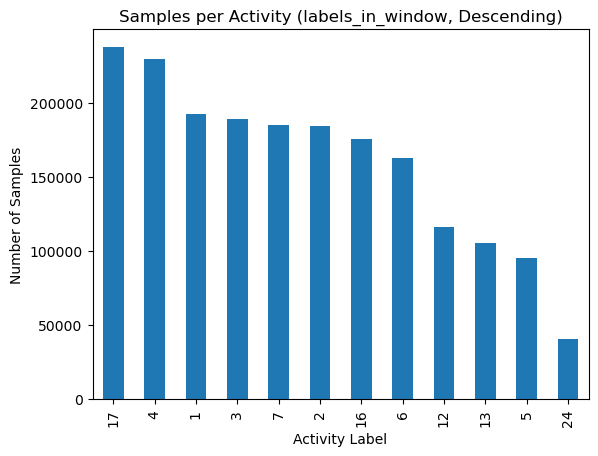

In [183]:
activity_counts_nadropped.plot(kind='bar')
plt.xlabel('Activity Label')
plt.ylabel('Number of Samples')
plt.title('Samples per Activity (labels_in_window, Descending)')
plt.show()

Ligeramente más pronunciado. E.g. 
24     42300
->
24     40500

## T2.5 Feature Extraction

In [186]:
pamap_windowed_nadropped.columns

Index(['timestamp', 'activityID', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'subject_id', 'window_number', 'window_id',
       'labels_in_window'],
      dtype='object')

In [187]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [188]:
import numpy as np
import pandas as pd

# Define sensor mappings
sensor_mappings = {
    'Hand': {
        'acc': ['IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z'],
        'gyro': ['IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z'],
        'mag': ['IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y', 'IMU_Hand_magnetometer_z']
    },
    'Chest': {
        'acc': ['IMU_Chest_acceleration_16g_x', 'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z'],
        'gyro': ['IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y', 'IMU_Chest_gyroscope_z'],
        'mag': ['IMU_Chest_magnetometer_x', 'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z']
    },
    'Ankle': {
        'acc': ['IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y', 'IMU_Ankle_acceleration_16g_z'],
        'gyro': ['IMU_Ankle_gyroscope_x', 'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z'],
        'mag': ['IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y', 'IMU_Ankle_magnetometer_z']
    }
}

# Define feature names
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

# Generate feature columns
feature_columns = [
    f"{sensor}_{sensor_type}_{feature}"
    for sensor in sensor_mappings
    for sensor_type in sensor_mappings[sensor]
    for feature in feature_names
]

# Initialize lists to store features and labels
numeric_features_list = []
labels = []

# Group data by subject, activity, and window number
grouped = pamap_windowed_nadropped.groupby(['subject_id', 'labels_in_window', 'window_number'])

# Iterate over each group
for (subject_id, activity_label, window_number), group in grouped:
    feature_vector = []

    for sensor_location, sensor_types in sensor_mappings.items():
        for sensor_type, axes in sensor_types.items():
            # Extract sensor data
            x = group[axes[0]].values
            y = group[axes[1]].values
            z = group[axes[2]].values

            # Compute features using InertialSensor class
            features = InertialSensor(x, y, z).extract_features()
            feature_vector.extend(features)

    # Append features and label
    numeric_features_list.append(feature_vector)
    labels.append(activity_label)

# Create DataFrame for features
df_numeric = pd.DataFrame(numeric_features_list, columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Concatenate features and labels
examples_db_nadropped = pd.concat([df_numeric, df_labels], axis=1)

# Display the resulting DataFrame
examples_db_nadropped.head()

,Hand_acc_mean_x,Hand_acc_mean_y,Hand_acc_mean_z,Hand_acc_std_x,Hand_acc_std_y,Hand_acc_std_z,Hand_acc_max_x,Hand_acc_max_y,Hand_acc_max_z,Hand_acc_corr_xy,...,Ankle_mag_max_y,Ankle_mag_max_z,Ankle_mag_corr_xy,Ankle_mag_corr_xz,Ankle_mag_corr_yz,Ankle_mag_mean_mag,Ankle_mag_std_mag,Ankle_mag_auc,Ankle_mag_mean_diff,activity
0,-0.046,8.142,4.661,1.915,1.429,1.829,3.089,11.615,8.316,-0.614,...,-35.508,-57.613,-0.938,-0.555,0.347,92.237,0.330,27671.160,0.000,1
1,-1.369,8.451,4.250,0.988,1.653,1.932,0.842,12.337,7.474,-0.481,...,-40.699,-58.204,-0.733,-0.487,0.345,92.571,0.311,27771.406,0.002,1
2,-0.895,8.675,1.951,2.275,0.936,3.266,2.815,11.479,6.351,0.507,...,-40.242,-42.089,0.265,-0.727,-0.845,93.447,1.277,28034.118,0.015,1
3,-6.479,2.705,3.806,3.681,4.182,3.236,2.716,9.833,8.228,0.508,...,42.984,-4.975,0.786,0.867,0.890,76.927,26.819,23078.155,-0.169,1
4,0.322,5.569,7.938,0.571,1.053,0.747,3.139,7.695,10.102,-0.136,...,44.947,-8.739,0.931,0.702,0.896,46.565,0.544,13969.563,0.004,1


In [189]:
examples_db_nadropped.shape

(6379, 145)

Esperamos tener 240 columnas de características + 1 columna de la etiqueta de la actividad

- (16 características por sensor) (3 sensores) + 1 label = 144 features + 1 label = 145 columnas

## T2.6 Escalamiento

In [192]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

## T2.7 Train/Test

In [194]:
from imblearn.pipeline import make_pipeline

In [195]:
X = examples_db_nadropped.drop(columns=["activity"], errors="ignore")
y = examples_db_nadropped["activity"]

# Codificar etiquetas si es necesario (por ejemplo, si activity no es numérica)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [196]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [197]:
pipe1 = make_pipeline(
    scaler, 
    nb
)

pipe1.fit(X, y_encoded)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

In [198]:
from sklearn.model_selection import cross_val_score

scorespipe = cross_val_score(pipe1, X, y_encoded, cv=10, scoring="f1_macro")
scorespipe

array([0.73982229, 0.88604046, 0.86640868, 0.8821299 , 0.90693599,
       0.85475639, 0.82827909, 0.8794155 , 0.84189657, 0.83197144])

In [199]:
np.average(scorespipe)

0.8517656308202852

## T2.8 Model comparison

In [262]:
X_2 = examples_db_nadropped.drop(columns=["activity"], errors="ignore")
y_2 = examples_db_nadropped.activity

from sklearn.preprocessing import LabelEncoder
le_2 = LabelEncoder()
y_encoded_2 = le_2.fit_transform(y)

In [263]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

def pipeleanear2(model, X, y, n_splits=10): 
    # definimos la estrategia del stratified k fold para que lo shufflee los ejemplos y que haga 10 splits y que sea estratificado
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    pipeline = make_pipeline(
        SMOTE(sampling_strategy='all', random_state=42), 
        scaler,  
        model
    )
    
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring="f1_macro")

    print("F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):")
    for i, score in enumerate(scores, 1):
        print(f"  Ronda {i}: {score:.4f}")
    
    avg_score = np.mean(scores)
    print(f"\nPromedio F1 Macro Score: {avg_score:.4f}")
    
    return scores

### T2.7.1 NB

In [265]:
from sklearn.naive_bayes import GaussianNB
nb_2 = GaussianNB()
nb_results_2 = pipeleanear2(nb_2, X_2, y_encoded_2)

nb_results_2.mean()

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.8639
  Ronda 2: 0.8835
  Ronda 3: 0.8830
  Ronda 4: 0.9011
  Ronda 5: 0.8806
  Ronda 6: 0.8952
  Ronda 7: 0.8662
  Ronda 8: 0.8775
  Ronda 9: 0.8940
  Ronda 10: 0.8651

Promedio F1 Macro Score: 0.8810


0.880997627740926

### T2.7.2 LR

In [267]:
from sklearn.linear_model import LogisticRegression
lr_2 = LogisticRegression(max_iter=1000)
lr_results_2 = pipeleanear2(lr_2, X_2, y_encoded_2)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9253
  Ronda 2: 0.9293
  Ronda 3: 0.9280
  Ronda 4: 0.9379
  Ronda 5: 0.9142
  Ronda 6: 0.9460
  Ronda 7: 0.8982
  Ronda 8: 0.9252
  Ronda 9: 0.9296
  Ronda 10: 0.9295

Promedio F1 Macro Score: 0.9263


### T2.7.3 RF

In [269]:
from sklearn.ensemble import RandomForestClassifier
rf_2 = RandomForestClassifier()
rf_results_2 = pipeleanear2(rf_2, X_2, y_encoded_2)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9292
  Ronda 2: 0.9433
  Ronda 3: 0.9396
  Ronda 4: 0.9486
  Ronda 5: 0.9426
  Ronda 6: 0.9543
  Ronda 7: 0.9361
  Ronda 8: 0.9371
  Ronda 9: 0.9413
  Ronda 10: 0.9409

Promedio F1 Macro Score: 0.9413


### T2.7.4 MLP

In [271]:
from sklearn.linear_model import Perceptron
perceptron_2 = Perceptron()
percep_results_2 = pipeleanear2(perceptron_2, X_2, y_encoded_2)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.8842
  Ronda 2: 0.9197
  Ronda 3: 0.9059
  Ronda 4: 0.9187
  Ronda 5: 0.8839
  Ronda 6: 0.9276
  Ronda 7: 0.8857
  Ronda 8: 0.9087
  Ronda 9: 0.9017
  Ronda 10: 0.8740

Promedio F1 Macro Score: 0.9010


### T2.7.5 XGBoost

In [273]:
from xgboost import XGBClassifier
xgb_2 = XGBClassifier()
xgb_results_2 = pipeleanear2(xgb_2, X_2, y_encoded_2)

F1 Macro Score por ronda de Stratified Cross-Validation (10 folds):
  Ronda 1: 0.9377
  Ronda 2: 0.9399
  Ronda 3: 0.9489
  Ronda 4: 0.9573
  Ronda 5: 0.9384
  Ronda 6: 0.9607
  Ronda 7: 0.9303
  Ronda 8: 0.9478
  Ronda 9: 0.9430
  Ronda 10: 0.9511

Promedio F1 Macro Score: 0.9455


Resultados

In [275]:
import pandas as pd

# Crear el diccionario con los resultados promedio de cada modelo
results_dict_2 = {
    "Naive Bayes": np.mean(nb_results_2),
    "Logistic Regression": np.mean(lr_results_2),
    "Random Forest": np.mean(rf_results_2),
    "Perceptron": np.mean(percep_results_2),
    "XGBoost": np.mean(xgb_results_2),
}

# Crear el DataFrame
results_df_2 = pd.DataFrame.from_dict(results_dict_2, orient='index', columns=["F1 Score"])
results_df_2.index.name = "Classifier"

# Mostrar resultados ordenados (opcional)
results_df_dropna = results_df_2.sort_values(by="F1 Score", ascending=False)

results_df_dropna

,F1 Score
Classifier,
XGBoost,0.946
Random Forest,0.941
Logistic Regression,0.926
Perceptron,0.901
Naive Bayes,0.881


# Tratamiento 1: Linear Interpolation

## T1.1 Linear Interpol

Para el primer método, aplicamos interpolación lineal sobre una deep copy para no modificar el dataset original. 

Las columnas originales completas:

In [8]:
deep_copy_pamap = pamap_data_filtered.copy().infer_objects()
deep_copy_pamap.columns

Index(['timestamp', 'activityID', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'subject_id'],
      dtype='object')

Nos quedamos solo con las de sensores:

In [9]:
sensor_columns = [
    'IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
    'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
    'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y', 'IMU_Hand_magnetometer_z',
    'IMU_Chest_acceleration_16g_x', 'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
    'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y', 'IMU_Chest_gyroscope_z',
    'IMU_Chest_magnetometer_x', 'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
    'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y', 'IMU_Ankle_acceleration_16g_z',
    'IMU_Ankle_gyroscope_x', 'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
    'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y', 'IMU_Ankle_magnetometer_z'
]


cols_to_interpolate = deep_copy_pamap[sensor_columns].copy()

print("Selected columns:", cols_to_interpolate.columns)

Selected columns: Index(['IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y',
       'IMU_Hand_acceleration_16g_z', 'IMU_Hand_gyroscope_x',
       'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z'],
      dtype='object')


Aplicamos linear interpolation

In [10]:
cols_to_interpolate.interpolate(method='linear', inplace=True)

print("Data after interpolation:")
cols_to_interpolate.head()

Data after interpolation:


,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,IMU_Hand_magnetometer_z,IMU_Chest_acceleration_16g_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
9588,-9.148,3.019,1.394,-0.042,0.032,-0.017,30.622,-4.996,-39.891,0.638,...,-11.626,-0.148,9.517,1.583,0.065,0.003,0.007,-34.501,-16.981,-2.948
9589,-9.104,2.982,1.587,-0.045,-0.027,0.003,31.114,-4.898,-39.367,0.606,...,-11.486,-0.069,9.363,1.739,0.061,-0.022,0.020,-33.878,-16.498,-3.372
9590,-9.066,3.020,1.588,-0.031,0.010,0.004,30.998,-5.512,-39.363,0.757,...,-11.488,-0.035,9.478,1.623,0.034,-0.039,-0.005,-34.517,-16.596,-3.658
9591,-9.067,3.020,1.549,-0.049,0.036,-0.025,30.997,-5.512,-39.232,0.644,...,-11.630,-0.187,9.555,1.505,0.003,0.040,0.003,-33.990,-16.877,-2.663
9592,-9.135,2.984,1.779,-0.025,-0.019,-0.041,31.118,-5.146,-39.497,0.718,...,-11.350,-0.147,9.440,1.622,0.014,-0.023,-0.002,-34.390,-16.214,-2.949


Armamos el nuevo dataset con los interpolados

In [14]:
import pandas as pd

# Identify the non-sensor (additional) columns from the original DataFrame.
other_columns = [col for col in deep_copy_pamap.columns if col not in sensor_columns]

# Extract the remaining columns from the original DataFrame.
other_data = deep_copy_pamap[other_columns].copy()

# Create a new DataFrame that concatenates the additional columns with the interpolated sensor data.
# Here we use pd.concat along the column axis.
interpolated_df = pd.concat([other_data, cols_to_interpolate], axis=1)

# Optionally, display the new DataFrame which now includes both sets of columns.
print("New DataFrame with interpolated sensor columns and additional data:")
interpolated_df.head()

New DataFrame with interpolated sensor columns and additional data:


,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
9588,101.770,1,subject106,-9.148,3.019,1.394,-0.042,0.032,-0.017,30.622,...,-11.626,-0.148,9.517,1.583,0.065,0.003,0.007,-34.501,-16.981,-2.948
9589,101.780,1,subject106,-9.104,2.982,1.587,-0.045,-0.027,0.003,31.114,...,-11.486,-0.069,9.363,1.739,0.061,-0.022,0.020,-33.878,-16.498,-3.372
9590,101.790,1,subject106,-9.066,3.020,1.588,-0.031,0.010,0.004,30.998,...,-11.488,-0.035,9.478,1.623,0.034,-0.039,-0.005,-34.517,-16.596,-3.658
9591,101.800,1,subject106,-9.067,3.020,1.549,-0.049,0.036,-0.025,30.997,...,-11.630,-0.187,9.555,1.505,0.003,0.040,0.003,-33.990,-16.877,-2.663
9592,101.810,1,subject106,-9.135,2.984,1.779,-0.025,-0.019,-0.041,31.118,...,-11.350,-0.147,9.440,1.622,0.014,-0.023,-0.002,-34.390,-16.214,-2.949


In [15]:
interpolated_df.shape

(1936481, 30)

Después de la interplolación, no quedan más faltantes

In [16]:
interpolated_df.isnull().sum()

timestamp                       0
activityID                      0
subject_id                      0
IMU_Hand_acceleration_16g_x     0
IMU_Hand_acceleration_16g_y     0
IMU_Hand_acceleration_16g_z     0
IMU_Hand_gyroscope_x            0
IMU_Hand_gyroscope_y            0
IMU_Hand_gyroscope_z            0
IMU_Hand_magnetometer_x         0
IMU_Hand_magnetometer_y         0
IMU_Hand_magnetometer_z         0
IMU_Chest_acceleration_16g_x    0
IMU_Chest_acceleration_16g_y    0
IMU_Chest_acceleration_16g_z    0
IMU_Chest_gyroscope_x           0
IMU_Chest_gyroscope_y           0
IMU_Chest_gyroscope_z           0
IMU_Chest_magnetometer_x        0
IMU_Chest_magnetometer_y        0
IMU_Chest_magnetometer_z        0
IMU_Ankle_acceleration_16g_x    0
IMU_Ankle_acceleration_16g_y    0
IMU_Ankle_acceleration_16g_z    0
IMU_Ankle_gyroscope_x           0
IMU_Ankle_gyroscope_y           0
IMU_Ankle_gyroscope_z           0
IMU_Ankle_magnetometer_x        0
IMU_Ankle_magnetometer_y        0
IMU_Ankle_magn

## T1.2 Median Filter

Observamos el dataset que vamos a aplicar el filtro:

In [41]:
interpolated_df.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
9588,101.770,1,subject106,-9.148,3.019,1.394,-0.042,0.032,-0.017,30.622,...,-11.626,-0.148,9.517,1.583,0.065,0.003,0.007,-34.501,-16.981,-2.948
9589,101.780,1,subject106,-9.104,2.982,1.587,-0.045,-0.027,0.003,31.114,...,-11.486,-0.069,9.363,1.739,0.061,-0.022,0.020,-33.878,-16.498,-3.372
9590,101.790,1,subject106,-9.066,3.020,1.588,-0.031,0.010,0.004,30.998,...,-11.488,-0.035,9.478,1.623,0.034,-0.039,-0.005,-34.517,-16.596,-3.658
9591,101.800,1,subject106,-9.067,3.020,1.549,-0.049,0.036,-0.025,30.997,...,-11.630,-0.187,9.555,1.505,0.003,0.040,0.003,-33.990,-16.877,-2.663
9592,101.810,1,subject106,-9.135,2.984,1.779,-0.025,-0.019,-0.041,31.118,...,-11.350,-0.147,9.440,1.622,0.014,-0.023,-0.002,-34.390,-16.214,-2.949


Revisamos las columnas irrelevantes para quitarlas:
- timestamp
- activityID
- subject_id

In [17]:
interpolated_df.columns

Index(['timestamp', 'activityID', 'subject_id', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z'],
      dtype='object')

Aplicamos el filtro en las columnas de sensores:

In [18]:
from scipy.ndimage import median_filter
import pandas as pd

def medianify_dataframe(df, exclude_columns=None, filter_size=3):
    if exclude_columns is None:
        exclude_columns = []

    df_copy = df.copy()
    columns_for_filter = df.columns.difference(exclude_columns)

    df_filtered = df_copy[columns_for_filter].apply(lambda col: median_filter(col, size=filter_size))
    df_final = pd.concat([df_copy[exclude_columns], df_filtered], axis=1)

    return df_final[df.columns]

In [19]:
pamap_interpol_median = medianify_dataframe(interpolated_df, 
                                 exclude_columns=['activityID', 'subject_id', 'timestamp'], 
                                 filter_size=3)
pamap_interpol_median.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Chest_magnetometer_z,IMU_Ankle_acceleration_16g_x,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z
9588,101.770,1,subject106,-9.148,3.019,1.394,-0.042,0.032,-0.017,30.622,...,-11.626,-0.148,9.517,1.583,0.065,0.003,0.007,-34.501,-16.981,-2.948
9589,101.780,1,subject106,-9.104,3.019,1.587,-0.042,0.010,0.003,30.998,...,-11.488,-0.069,9.478,1.623,0.061,-0.022,0.007,-34.501,-16.596,-3.372
9590,101.790,1,subject106,-9.067,3.020,1.587,-0.045,0.010,0.003,30.998,...,-11.488,-0.069,9.478,1.623,0.034,-0.022,0.003,-33.990,-16.596,-3.372
9591,101.800,1,subject106,-9.067,3.020,1.588,-0.031,0.010,-0.025,30.998,...,-11.488,-0.147,9.478,1.622,0.014,-0.023,-0.002,-34.390,-16.596,-2.949
9592,101.810,1,subject106,-9.135,2.984,1.585,-0.031,-0.017,-0.025,30.997,...,-11.350,-0.151,9.555,1.505,0.014,-0.005,0.003,-34.261,-16.350,-2.949


Observamos la diferencia y notamos que se reduce en los puntos más extremos

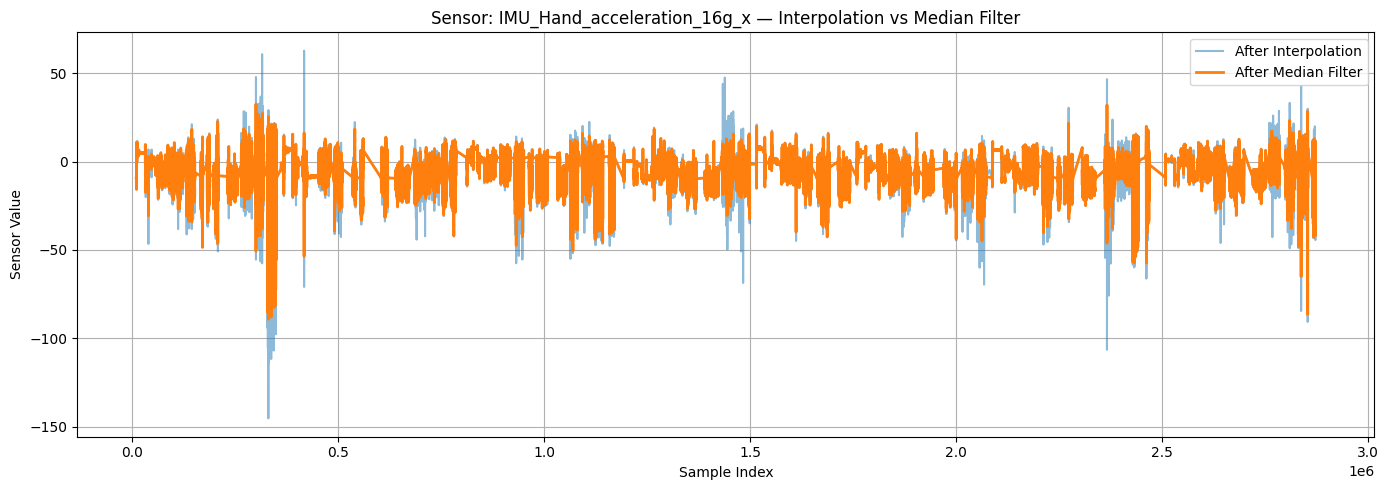

In [45]:
import matplotlib.pyplot as plt

# Choose a sensor column to visualize
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Extract signals
original = interpolated_df[sensor_column]
medianed = pamap_interpol_median[sensor_column]

# Plot comparison
plt.figure(figsize=(14, 5))
plt.plot(original, label='After Interpolation', alpha=0.5)
plt.plot(medianed, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — Interpolation vs Median Filter')
plt.xlabel('Sample Index')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Para observar bien los efectos anaizamos una ventana de tiempo de 300 (equivalente a 3s dado que son 100Hz).

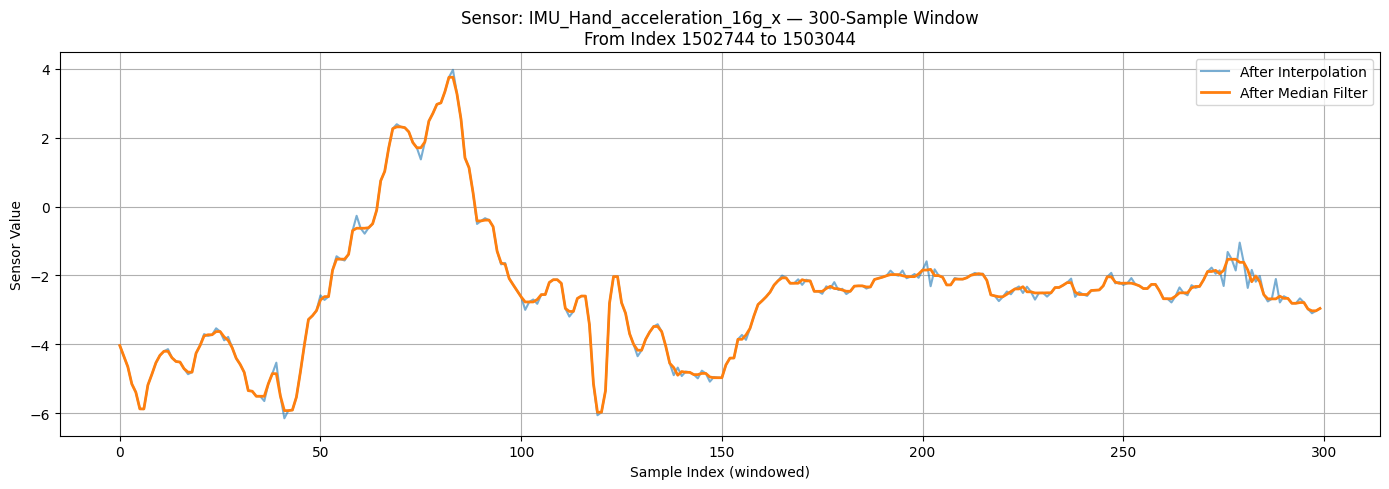

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the sensor column
sensor_column = 'IMU_Hand_acceleration_16g_x'

# Total number of samples available
total_samples = len(interpolated_df)

# Choose random starting index such that we can take 300 samples without going out of bounds
start_idx = np.random.randint(0, total_samples - 300)

# Slice the 300-sample window
original = interpolated_df[sensor_column].iloc[start_idx:start_idx + 300]
medianed = pamap_interpol_median[sensor_column].iloc[start_idx:start_idx + 300]

# Plot
plt.figure(figsize=(14, 5))
plt.plot(original.values, label='After Interpolation', alpha=0.6)
plt.plot(medianed.values, label='After Median Filter', linewidth=2)
plt.title(f'Sensor: {sensor_column} — 300-Sample Window\nFrom Index {start_idx} to {start_idx + 300}')
plt.xlabel('Sample Index (windowed)')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## T1.3 Segmentación

In [47]:
import pandas as pd

def segment_by_window(group, window_size):
    """
    Segments data into windows of specified size.

    Args:
        group (pd.DataFrame): Subject's data.
        window_size (int): Size of each time window.

    Returns:
        list: List of DataFrames, each representing a window of data.
    """
    windows = []
    for start in range(0, len(group), window_size):
        end = start + window_size
        if end <= len(group):
            window = group.iloc[start:end].copy()
            windows.append(window)
    return windows

def add_window_metadata(windows, subject_id):
    """
    Adds metadata like window number, window ID, and majority label.

    Args:
        windows (list): List of window DataFrames.
        subject_id (int): Subject identifier.

    Returns:
        list: List of windows with added metadata.
    """
    for i, window in enumerate(windows):
        window['subject_id'] = subject_id
        window['window_number'] = i
        window['window_id'] = f"{subject_id}_{window['window_number'].iloc[0]}"

        majority_label = get_majority_label(window)
        window['labels_in_window'] = [majority_label] * len(window)
    return windows

def get_majority_label(window):
    """
    Gets the majority label for a window.

    Args:
        window (pd.DataFrame): Window data.

    Returns:
        str: Majority label, or None if no majority.
    """
    label_counts = window['activityID'].value_counts()
    majority_label = label_counts.idxmax() if label_counts.max() / len(window) > 0.5 else window['label'].iloc[0]
    return majority_label

def process_subject_data(mhealth_df, window_size):
    """
    Processes all subject data by segmenting and adding metadata.

    Args:
        mhealth_df (pd.DataFrame): Data of multiple subjects.
        window_size (int): Size of each time window.

    Returns:
        list: List of windows with metadata.
    """
    all_windows = []
    for subject_id, group in mhealth_df.groupby('subject_id'):
        group = group.reset_index(drop=True)

        windows = segment_by_window(group, window_size)
        windows = add_window_metadata(windows, subject_id)
        all_windows.extend(windows)
    
    return all_windows

def concatenate_windows(windows):
    """
    Concatenates all windows into a single DataFrame.

    Args:
        windows (list): List of window DataFrames.

    Returns:
        pd.DataFrame: Concatenated DataFrame of all windows.
    """
    return pd.concat(windows).reset_index(drop=True)

def display_basic_info(ventanas_df, windows):
    """
    Displays basic info about windows and their majority labels.

    Args:
        ventanas_df (pd.DataFrame): DataFrame of windows with metadata.
        windows (list): List of processed windows.
    """
    for window_id, group in ventanas_df.groupby('window_id'):
        majority_label = group['labels_in_window'].iloc[0]

# Parameters
window_size = 300  # 3 seconds * 100 Hz

print(pamap_data.shape)
windows = process_subject_data(interpolated_df, window_size)

# Concatenate all windows into a single DataFrame
pamap_windowed = concatenate_windows(windows)

(1936481, 55)


In [30]:
pamap_windowed.head()

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,window_number,window_id,labels_in_window
0,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,0,subject101_0,1
1,37.670,1,subject101,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,...,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366,0,subject101_0,1
2,37.680,1,subject101,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,...,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612,0,subject101_0,1
3,37.690,1,subject101,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,...,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880,0,subject101_0,1
4,37.700,1,subject101,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,...,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885,0,subject101_0,1


In [115]:
# window_measurement_counts_df = window_measurement_counts.reset_index(name='num_measurements')
# window_measurement_counts_df

## T1.4 Class imbalance

There's a pronounced class imbalance with the class 24, 5, 13 and 12

In [118]:
# Count and sort samples per activity using 'labels_in_window'
activity_counts = pamap_windowed['labels_in_window'].value_counts().sort_values(ascending=False)

# Display the result
activity_counts

labels_in_window
17    238500
4     238200
1     192600
3     189600
7     188100
2     185400
16    175500
6     164700
12    117300
13    105300
5      97800
24     42300
Name: count, dtype: int64

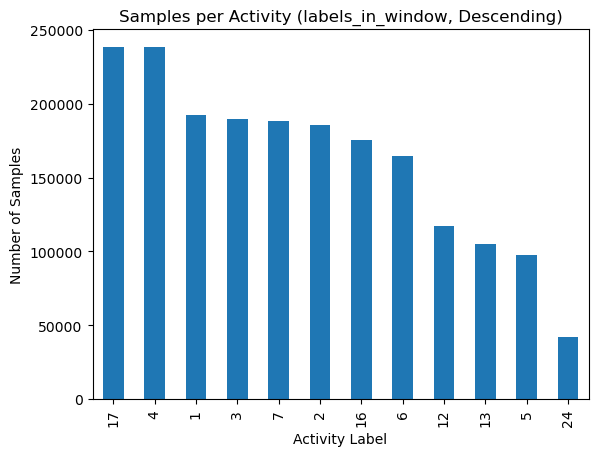

In [119]:
activity_counts.plot(kind='bar')
plt.xlabel('Activity Label')
plt.ylabel('Number of Samples')
plt.title('Samples per Activity (labels_in_window, Descending)')
plt.show()

## T1.5 Feature Extraction

In [34]:
pamap_windowed.columns

Index(['timestamp', 'activityID', 'subject_id', 'IMU_Hand_acceleration_16g_x',
       'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z',
       'IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z',
       'IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y',
       'IMU_Hand_magnetometer_z', 'IMU_Chest_acceleration_16g_x',
       'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z',
       'IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y',
       'IMU_Chest_gyroscope_z', 'IMU_Chest_magnetometer_x',
       'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z',
       'IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y',
       'IMU_Ankle_acceleration_16g_z', 'IMU_Ankle_gyroscope_x',
       'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z',
       'IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y',
       'IMU_Ankle_magnetometer_z', 'window_number', 'window_id',
       'labels_in_window'],
      dtype='object')

In [23]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [50]:
import numpy as np
import pandas as pd

# Define sensor mappings
sensor_mappings = {
    'Hand': {
        'acc': ['IMU_Hand_acceleration_16g_x', 'IMU_Hand_acceleration_16g_y', 'IMU_Hand_acceleration_16g_z'],
        'gyro': ['IMU_Hand_gyroscope_x', 'IMU_Hand_gyroscope_y', 'IMU_Hand_gyroscope_z'],
        'mag': ['IMU_Hand_magnetometer_x', 'IMU_Hand_magnetometer_y', 'IMU_Hand_magnetometer_z']
    },
    'Chest': {
        'acc': ['IMU_Chest_acceleration_16g_x', 'IMU_Chest_acceleration_16g_y', 'IMU_Chest_acceleration_16g_z'],
        'gyro': ['IMU_Chest_gyroscope_x', 'IMU_Chest_gyroscope_y', 'IMU_Chest_gyroscope_z'],
        'mag': ['IMU_Chest_magnetometer_x', 'IMU_Chest_magnetometer_y', 'IMU_Chest_magnetometer_z']
    },
    'Ankle': {
        'acc': ['IMU_Ankle_acceleration_16g_x', 'IMU_Ankle_acceleration_16g_y', 'IMU_Ankle_acceleration_16g_z'],
        'gyro': ['IMU_Ankle_gyroscope_x', 'IMU_Ankle_gyroscope_y', 'IMU_Ankle_gyroscope_z'],
        'mag': ['IMU_Ankle_magnetometer_x', 'IMU_Ankle_magnetometer_y', 'IMU_Ankle_magnetometer_z']
    }
}

# Define feature names
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

# Generate feature columns
feature_columns = [
    f"{sensor}_{sensor_type}_{feature}"
    for sensor in sensor_mappings
    for sensor_type in sensor_mappings[sensor]
    for feature in feature_names
]

# Initialize lists to store features and labels
numeric_features_list = []
labels = []

# Group data by subject, activity, and window number
grouped = pamap_windowed.groupby(['subject_id', 'labels_in_window', 'window_number'])

# Iterate over each group
for (subject_id, activity_label, window_number), group in grouped:
    feature_vector = []

    for sensor_location, sensor_types in sensor_mappings.items():
        for sensor_type, axes in sensor_types.items():
            # Extract sensor data
            x = group[axes[0]].values
            y = group[axes[1]].values
            z = group[axes[2]].values

            # Compute features using InertialSensor class
            features = InertialSensor(x, y, z).extract_features()
            feature_vector.extend(features)

    # Append features and label
    numeric_features_list.append(feature_vector)
    labels.append(activity_label)

# Create DataFrame for features
df_numeric = pd.DataFrame(numeric_features_list, columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Concatenate features and labels
examples_db = pd.concat([df_numeric, df_labels], axis=1)

# Display the resulting DataFrame
examples_db.head()

,Hand_acc_mean_x,Hand_acc_mean_y,Hand_acc_mean_z,Hand_acc_std_x,Hand_acc_std_y,Hand_acc_std_z,Hand_acc_max_x,Hand_acc_max_y,Hand_acc_max_z,Hand_acc_corr_xy,...,Ankle_mag_max_y,Ankle_mag_max_z,Ankle_mag_corr_xy,Ankle_mag_corr_xz,Ankle_mag_corr_yz,Ankle_mag_mean_mag,Ankle_mag_std_mag,Ankle_mag_auc,Ankle_mag_mean_diff,activity
0,-0.052,8.141,4.655,1.922,1.454,1.848,3.185,12.012,8.698,-0.610,...,-35.186,-57.114,-0.919,-0.467,0.273,92.245,0.422,27673.603,-0.000,1
1,-1.367,8.450,4.254,0.996,1.676,1.945,0.879,12.452,7.589,-0.470,...,-39.917,-57.708,-0.644,-0.397,0.244,92.565,0.407,27769.644,-0.000,1
2,-0.897,8.672,1.951,2.279,0.948,3.268,3.032,11.704,6.764,0.501,...,-39.938,-41.964,0.265,-0.723,-0.843,93.445,1.310,28033.450,0.013,1
3,-6.484,2.710,3.805,3.692,4.197,3.241,2.818,10.664,8.537,0.506,...,43.483,-3.827,0.786,0.867,0.890,76.940,26.830,23081.985,-0.170,1
4,0.320,5.569,7.941,0.581,1.058,0.753,3.139,7.765,10.335,-0.130,...,45.254,-8.118,0.924,0.694,0.886,46.567,0.622,13969.956,0.003,1


In [51]:
examples_db.shape

(6451, 145)

Esperamos tener 240 columnas de características + 1 columna de la etiqueta de la actividad

- (16 características por sensor) (3 sensores) + 1 label = 144 features + 1 label = 145 columnas

## T1.6 Escalamiento

Se usa z-score

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

## T1.7 Train/Test

Importamos la pipeline para hacerlo

In [53]:
from imblearn.pipeline import make_pipeline

Separamos los ejemplos de los labels

In [54]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db["activity"]

# Codificar etiquetas si es necesario (por ejemplo, si activity no es numérica)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Usamos NB para bootstrapping

In [55]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

Fitteamos el modelo

In [56]:
pipe1 = make_pipeline(
    scaler, 
    nb
)

pipe1.fit(X, y_encoded)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

Aplicamos el CV para obtener resultados

In [57]:
from sklearn.model_selection import cross_val_score

scorespipe = cross_val_score(pipe1, X, y_encoded, cv=10, scoring="f1_macro")
scorespipe

array([0.77099262, 0.87786001, 0.85863794, 0.88103775, 0.89542253,
       0.82716522, 0.84529726, 0.86502486, 0.83683267, 0.83592167])

In [43]:
np.average(scorespipe)

np.float64(0.8494192532062428)

## T1.8 Model comparison

In [189]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [59]:
def stats_arr(arr):
    return {
        "Media:":     np.mean(arr),
        "Mediana:":   np.median(arr),
        "Std:":       np.std(arr),
        "Mínimo:":    np.min(arr),
        "Máximo:":    np.max(arr),
    }

In [60]:
def print_metrics(cv_results):
    print("Scores (F1-macro):")
    f1_scores = cv_results["test_f1_macro"]
    for i in range(0, len(f1_scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in f1_scores[i:i+5]))
    
    print()
    stats_scores = stats_arr(f1_scores)
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    times = cv_results["fit_time"]
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    stats_times = stats_arr(times)
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    

In [61]:
import time
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
import numpy as np

def execute_pipeline(model, X, y):
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler()
    
    pipe = make_pipeline(smote, scaler, model)

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    print(cv_results)
    
    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }

        all_scores.append(fold_scores)
        
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    print_metrics(cv_results)

    return scores, times, all_scores

### T1.7.1 NB

In [62]:
from sklearn.naive_bayes import GaussianNB
nb_1 = GaussianNB()
nb_results_1 = execute_pipeline(nb_1, X, y)

{'fit_time': array([0.185987  , 0.11521101, 0.08682346, 0.12834239, 0.11361599,
       0.09521127, 0.07705832, 0.10714483, 0.08956361, 0.09279561]), 'score_time': array([0.00878906, 0.00871706, 0.00867152, 0.00869918, 0.00899386,
       0.00857139, 0.00859928, 0.00869465, 0.00872564, 0.00871396]), 'test_f1_macro': array([0.87941537, 0.89352457, 0.88767056, 0.87340449, 0.89013572,
       0.8794774 , 0.87841484, 0.88920801, 0.88129335, 0.86867345]), 'test_accuracy': array([0.87770898, 0.88837209, 0.88062016, 0.87286822, 0.89302326,
       0.86976744, 0.8744186 , 0.87906977, 0.88062016, 0.8744186 ]), 'test_precision_macro': array([0.89170516, 0.8986526 , 0.89869025, 0.89408007, 0.90753839,
       0.88625481, 0.89122446, 0.89745697, 0.89652053, 0.88582255]), 'test_recall_macro': array([0.87249054, 0.89144059, 0.88081914, 0.86271304, 0.88007077,
       0.87750944, 0.87513087, 0.88487051, 0.87301812, 0.8596427 ])}
Scores (F1-macro):
  0.8794  0.8935  0.8877  0.8734  0.8901
  0.8795  0.8784  

### T1.7.2 LR

In [190]:
from sklearn.linear_model import LogisticRegression
lr_1 = LogisticRegression(max_iter=1000)
lr_results_1 = execute_pipeline(lr_1, X, y_encoded)

{'fit_time': array([14.03455186, 13.69966149, 14.93804646, 14.0718267 , 13.33840275,
       15.25962019, 15.16440916, 15.61886191, 15.50194049, 12.36945248]), 'score_time': array([0.00686169, 0.00676537, 0.01852965, 0.00684023, 0.0141542 ,
       0.00762606, 0.00671101, 0.00673056, 0.01607943, 0.00740528]), 'test_f1_macro': array([0.91878415, 0.94007948, 0.92098318, 0.91216755, 0.9225024 ,
       0.90834557, 0.92931706, 0.92720103, 0.91276839, 0.92919871]), 'test_accuracy': array([0.91950464, 0.94108527, 0.92868217, 0.92248062, 0.93488372,
       0.91472868, 0.93333333, 0.93333333, 0.92713178, 0.93953488]), 'test_precision_macro': array([0.92774269, 0.94236336, 0.92231373, 0.92082205, 0.9262304 ,
       0.90532944, 0.94206987, 0.92633694, 0.91281724, 0.93060867]), 'test_recall_macro': array([0.91257291, 0.93924965, 0.92189913, 0.90789324, 0.91955118,
       0.91337709, 0.92339469, 0.93041725, 0.91524207, 0.92820793])}
Scores (F1-macro):
  0.9188  0.9401  0.9210  0.9122  0.9225
  0.9083

### T1.7.3 RF

In [63]:
from sklearn.ensemble import RandomForestClassifier
rf_1 = RandomForestClassifier()
rf_results_1 = execute_pipeline(rf_1, X, y_encoded)

{'fit_time': array([8.57876229, 8.57909155, 8.34790039, 8.48434806, 8.49445105,
       8.42862701, 8.36150765, 8.43518353, 8.41078091, 8.37234116]), 'score_time': array([0.01520061, 0.01509762, 0.0151422 , 0.01549482, 0.01468682,
       0.01498365, 0.01493382, 0.01483631, 0.01488733, 0.01490855]), 'test_f1_macro': array([0.93192404, 0.9482534 , 0.94360707, 0.9213909 , 0.93555967,
       0.93244053, 0.95064866, 0.94292858, 0.94099755, 0.93378479]), 'test_accuracy': array([0.93498452, 0.95348837, 0.94883721, 0.92868217, 0.94263566,
       0.93178295, 0.95193798, 0.94573643, 0.9503876 , 0.9379845 ]), 'test_precision_macro': array([0.93980761, 0.94875647, 0.94697697, 0.93455015, 0.94571393,
       0.93735798, 0.95646595, 0.94674892, 0.9454261 , 0.9446266 ]), 'test_recall_macro': array([0.92633016, 0.94925827, 0.94176226, 0.91324873, 0.92863095,
       0.92979683, 0.94730883, 0.9409776 , 0.93775744, 0.9256463 ])}
Scores (F1-macro):
  0.9319  0.9483  0.9436  0.9214  0.9356
  0.9324  0.9506  

### T1.7.4 MLP

In [64]:
from sklearn.linear_model import Perceptron
perceptron_1 = Perceptron()
percep_results_1 = execute_pipeline(perceptron_1, X, y_encoded)

{'fit_time': array([0.57860804, 0.63905001, 0.6479516 , 0.61047578, 0.63509679,
       0.67472577, 0.60499477, 0.69259906, 0.63771629, 0.64933062]), 'score_time': array([0.00633621, 0.00607657, 0.00619864, 0.00607681, 0.00610042,
       0.00609541, 0.00612307, 0.00616622, 0.00609469, 0.00603986]), 'test_f1_macro': array([0.90546079, 0.92698833, 0.91145945, 0.87450201, 0.90551149,
       0.89326193, 0.90520102, 0.90962031, 0.90235659, 0.91795884]), 'test_accuracy': array([0.91176471, 0.9255814 , 0.90852713, 0.88372093, 0.92093023,
       0.90077519, 0.90697674, 0.91007752, 0.91627907, 0.9255814 ]), 'test_precision_macro': array([0.91142306, 0.93349108, 0.92550945, 0.88813859, 0.9056848 ,
       0.88950793, 0.91188478, 0.91362353, 0.90425323, 0.9196341 ]), 'test_recall_macro': array([0.90322306, 0.92673792, 0.90481497, 0.87242142, 0.90704595,
       0.9035979 , 0.91083535, 0.90814637, 0.90482058, 0.91827468])}
Scores (F1-macro):
  0.9055  0.9270  0.9115  0.8745  0.9055
  0.8933  0.9052  

### T1.7.7 Voting Classifier

In [59]:
pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.5 MB/s eta 0:00:000:00:010:00:01:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_results_1 = execute_pipeline(eclf, X, y)

### AdaBoost

In [65]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_results_1 = execute_pipeline(ada, X, y_encoded)

{'fit_time': array([65.65938973, 65.29337668, 65.39843273, 65.50266385, 65.36569357,
       64.88509035, 64.96027446, 64.9825294 , 65.2589891 , 65.48354411]), 'score_time': array([0.02370644, 0.02310562, 0.02281761, 0.02678466, 0.0228138 ,
       0.02307177, 0.02277946, 0.0227921 , 0.02269816, 0.0229857 ]), 'test_f1_macro': array([0.929697  , 0.94994627, 0.926067  , 0.92350274, 0.94185818,
       0.93501149, 0.93512408, 0.927499  , 0.93749298, 0.93395036]), 'test_accuracy': array([0.93962848, 0.95348837, 0.93643411, 0.93488372, 0.9503876 ,
       0.93488372, 0.9379845 , 0.93178295, 0.94263566, 0.94263566]), 'test_precision_macro': array([0.9280403 , 0.94803202, 0.9238083 , 0.93487718, 0.94711212,
       0.93616157, 0.93900421, 0.9292656 , 0.9413507 , 0.93497918]), 'test_recall_macro': array([0.93323809, 0.95379095, 0.93039213, 0.91762063, 0.93849948,
       0.93551134, 0.93496732, 0.92703013, 0.93522147, 0.93420759])}
Scores (F1-macro):
  0.9297  0.9499  0.9261  0.9235  0.9419
  0.9350

Resultados

In [191]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    f1s, accs, precs, recalls = [], [], [], []

    for fold in classifier_results[2]:
        f1s.append(fold["f1_macro"])
        accs.append(fold["accuracy"])
        precs.append(fold["precision_macro"])
        recalls.append(fold["recall_macro"])

    metrics = {
        "f1_macro": agg_func(f1s),
        "accuracy": agg_func(accs),
        "precision_macro": agg_func(precs),
        "recall_macro": agg_func(recalls)
    }
    return metrics

# Ejemplo de uso
nb_mean_metrics = compute_metrics(nb_results_1)
lr_mean_metrics = compute_metrics(lr_results_1)
rf_mean_metrics = compute_metrics(rf_results_1)
percep_mean_metrics = compute_metrics(percep_results_1)
ada_mean_metrics = compute_metrics(ada_results_1)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics,
    "Adaboost": ada_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.88212,0.87909,0.89479,0.87577
Logistic Regression,0.92213,0.92947,0.92566,0.92118
Random Forest,0.93815,0.94265,0.94464,0.93407
Perceptron,0.90523,0.91102,0.91032,0.90599
Adaboost,0.93401,0.94047,0.93626,0.93405


## Conclusión

No parece haber diferencia significativa. Se prefiere Linear Interpolation porque es más fácil de usar, argumentar, y da mejores resultados en XGBoost que es uno de los que podríamos usar para proponer.

# PCA

## Definición de nuevo de los datos

In [66]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## PCA

In [67]:
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from imblearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.over_sampling import SMOTE

def pipeline_pca(model, X, y):
    print("Original feature count:", X.shape[1])
    pca = PCA(n_components=0.95)
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler()

    pipe = make_pipeline(smote, scaler, pca, model)
    pipe.fit(X, y)    
    print("Feature count after PCA:", pca.n_components_)
    
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, 
        y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    
    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)
        
        
    # extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    print_metrics(cv_results)
    
    return scores, times, all_scores

### Native Bayes (PCA)

In [68]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_results = pipeline_pca(nb, X, y_encoded)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.8704  0.8762  0.8636  0.8655  0.8756
  0.8606  0.8627  0.8799  0.8630  0.8575

Media:              0.8675
Mediana:            0.8646
Std:                0.0072
Mínimo:             0.8575
Máximo:             0.8799

Tiempos de entrenamiento (s):
  0.2038  0.2208  0.2130  0.2098  0.2080
  0.2067  0.2126  0.1979  0.1980  0.2178

Media:              0.2088
Mediana:            0.2089
Std:                0.0072
Mínimo:             0.1979
Máximo:             0.2208


### Regreseión Logística (PCA)

In [69]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_results = pipeline_pca(lr, X, y_encoded)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.8897  0.9142  0.9063  0.8858  0.9209
  0.8929  0.9061  0.8937  0.8959  0.9244

Media:              0.9030
Mediana:            0.9010
Std:                0.0128
Mínimo:             0.8858
Máximo:             0.9244

Tiempos de entrenamiento (s):
  6.6313  6.5049  5.5482  7.4668  6.8435
  6.6474  7.5233  6.5199  4.8332  6.0835

Media:              6.4602
Mediana:            6.5756
Std:                0.7734
Mínimo:             4.8332
Máximo:             7.5233


### Bloques aleatorios (PCA)

In [70]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_results = pipeline_pca(rf, X, y_encoded)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.9076  0.9395  0.9122  0.9146  0.9246
  0.9268  0.9298  0.9168  0.9231  0.9133

Media:              0.9209
Mediana:            0.9200
Std:                0.0092
Mínimo:             0.9076
Máximo:             0.9395

Tiempos de entrenamiento (s):
  5.4205  5.5541  5.5625  5.5687  5.4610
  5.6071  5.5201  5.5482  5.4546  5.5009

Media:              5.5198
Mediana:            5.5341
Std:                0.0564
Mínimo:             5.4205
Máximo:             5.6071


### Perceptron (PCA)

In [71]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_results = pipeline_pca(perceptron, X, y_encoded)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.8594  0.8705  0.8669  0.8604  0.8712
  0.8376  0.8921  0.8605  0.8813  0.8789

Media:              0.8679
Mediana:            0.8687
Std:                0.0142
Mínimo:             0.8376
Máximo:             0.8921

Tiempos de entrenamiento (s):
  0.2006  0.3631  0.3538  0.3284  0.3164
  0.3495  0.3103  0.3184  0.3210  0.3432

Media:              0.3205
Mediana:            0.3247
Std:                0.0434
Mínimo:             0.2006
Máximo:             0.3631


### Voting Classifier (PCA)

In [87]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_pca_results = pipeline_pca(eclf, X, y)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.9030  0.9310  0.9014  0.8916  0.9126
  0.9161  0.9105  0.9068  0.9033  0.9110

Media:              0.9087
Mediana:            0.9086
Std:                0.0099
Mínimo:             0.8916
Máximo:             0.9310

Tiempos de entrenamiento (s):
  12.5823  12.7734  11.2669  11.3634  12.0511
  12.3436  13.5100  12.2463  10.8289  10.5345

Media:              11.9500
Mediana:            12.1487
Std:                0.8852
Mínimo:             10.5345
Máximo:             13.5100


### AadaBoost (PCA)

In [72]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_pca_results = pipeline_pca(ada, X, y_encoded)

Original feature count: 144
Feature count after PCA: 61
Scores (F1-macro):
  0.8838  0.8864  0.8714  0.8707  0.8585
  0.8539  0.8694  0.8871  0.8621  0.8467

Media:              0.8690
Mediana:            0.8700
Std:                0.0132
Mínimo:             0.8467
Máximo:             0.8871

Tiempos de entrenamiento (s):
  27.6276  28.2804  27.7801  27.8145  27.7081
  28.1978  27.7178  28.1195  27.8881  27.7873

Media:              27.8921
Mediana:            27.8009
Std:                0.2144
Mínimo:             27.6276
Máximo:             28.2804


## Comparativa PCA vs no PCA

In [192]:
import numpy as np
import pandas as pd

# Construimos el DataFrame usando la mediana, con nombres de columna limpios
performance_comparison_PCA = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.median(nb_results_1[0]),
        "Con PCA": np.median(nb_pca_results[0])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.median(lr_results_1[0]),
        "Con PCA": np.median(lr_pca_results[0])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.median(rf_results_1[0]),
        "Con PCA": np.median(rf_pca_results[0])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.median(percep_results_1[0]),
        "Con PCA": np.median(percep_pca_results[0])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.median(ada_results_1[0]),
        "Con PCA": np.median(ada_pca_results[0])
    }
])

performance_comparison_PCA.set_index("Clasificador", inplace=True)
performance_comparison_PCA

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.880,0.865
Regresión Logística,0.922,0.901
Bosques Aleatorios,0.938,0.920
Perceptrón,0.905,0.869
Perceptrón,0.934,0.870


## Comparación de métodos con PCA

In [193]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    f1s, accs, precs, recalls = [], [], [], []

    for fold in classifier_results[2]:
        f1s.append(fold["f1_macro"])
        accs.append(fold["accuracy"])
        precs.append(fold["precision_macro"])
        recalls.append(fold["recall_macro"])

    metrics = {
        "f1_macro": agg_func(f1s),
        "accuracy": agg_func(accs),
        "precision_macro": agg_func(precs),
        "recall_macro": agg_func(recalls)
    }
    return metrics

# Ejemplo de uso
nb_mean_metrics = compute_metrics(nb_pca_results)
lr_mean_metrics = compute_metrics(lr_pca_results)
rf_mean_metrics = compute_metrics(rf_pca_results)
percep_mean_metrics = compute_metrics(percep_pca_results)
ada_mean_metrics = compute_metrics(ada_pca_results)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics,
    "Adaboost": ada_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.86750,0.86514,0.88080,0.86190
Logistic Regression,0.90300,0.91087,0.90341,0.90550
Random Forest,0.92085,0.92327,0.93123,0.91420
Perceptron,0.86788,0.87118,0.87442,0.87045
Adaboost,0.86901,0.87149,0.87798,0.86673


## Wilcoxon

In [58]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_results_1[0]),        np.array(nb_pca_results[0])),
    "Regresión Logística":           (np.array(lr_results_1[0]),        np.array(lr_pca_results[0])),
    "Bosques Aleatorios":            (np.array(rf_results_1[0]),        np.array(rf_pca_results[0])),
    "Perceptrón":                    (np.array(percep_results_1[0]),    np.array(percep_pca_results[0])),
    "Voting Classifier":             (np.array(eclf_results_1[0]),    np.array(eclf_pca_results[0])),
    "Adaboost":             (np.array(ada_results_1[0]),    np.array(ada_pca_results[0]))
}


alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

NameError: name 'nb_pca_results' is not defined

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# Tu diccionario
scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_results_1[0]),        np.array(nb_pca_results[0])),
    "Regresión Logística":           (np.array(lr_results_1[0]),        np.array(lr_pca_results[0])),
    "Bosques Aleatorios":            (np.array(rf_results_1[0]),        np.array(rf_pca_results[0])),
    "Perceptrón":                    (np.array(percep_results_1[0]),    np.array(percep_pca_results[0])),
    "Voting Classifier":             (np.array(eclf_results_1[0]),      np.array(eclf_pca_results[0])),
    "Adaboost":                      (np.array(ada_results_1[0]),       np.array(ada_pca_results[0]))
}

# Combinar todos los resultados en dos arrays
f1_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
f1_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert f1_sin_pca.shape == f1_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(f1_sin_pca, f1_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

## Tiempos de entrenamiento PCA vs NO PCA

In [94]:
import numpy as np
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results_1[1]),
        "Con PCA": np.mean(nb_pca_results[1])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results_1[1]),
        "Con PCA": np.mean(lr_pca_results[1])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results_1[1]),
        "Con PCA": np.mean(rf_pca_results[1])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results_1[1]),
        "Con PCA": np.mean(percep_pca_results[1])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.median(eclf_results_1[1]),
        "Con PCA": np.median(eclf_pca_results[1])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.median(ada_results_1[1]),
        "Con PCA": np.median(ada_pca_results[1])
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.113,0.246
Regresión Logística,15.586,6.466
Bosques Aleatorios,8.467,5.551
Perceptrón,0.648,0.345
XGBoost,3.565,2.445
Bagging Tree,48.374,23.993
Voting Classifier,23.032,12.149


In [92]:
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results_1[1]),
        "Con PCA": np.mean(nb_pca_results[1])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results_1[1]),
        "Con PCA": np.mean(lr_pca_results[1])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results_1[1]),
        "Con PCA": np.mean(rf_pca_results[1])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results_1[1]),
        "Con PCA": np.mean(percep_pca_results[1])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.median(eclf_results_1[1]),
        "Con PCA": np.median(eclf_pca_results[1])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.median(ada_results_1[1]),
        "Con PCA": np.median(ada_pca_results[1])
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.113,0.246
Regresión Logística,15.586,6.466
Bosques Aleatorios,8.467,5.551
Perceptrón,0.648,0.345
XGBoost,3.565,2.445
Bagging Classifier,48.374,23.993
Voting Classifier,23.032,12.149


In [93]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_results_1[metric_idx]),              np.array(nb_pca_results[metric_idx])),
    "Regresión Logística":           (np.array(lr_results_1[metric_idx]),              np.array(lr_pca_results[metric_idx])),
    "Bosques Aleatorios":            (np.array(rf_results_1[metric_idx]),              np.array(rf_pca_results[metric_idx])),
    "Perceptrón":                    (np.array(percep_results_1[metric_idx]),          np.array(percep_pca_results[metric_idx])),
    "Voting":                        (np.array(eclf_results_1[metric_idx]),            np.array(eclf_pca_results[metric_idx])),
    "Adaboost":                      (np.array(ada_results_1[metric_idx]),             np.array(ada_pca_results[metric_idx])),
}


alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

,Sin PCA,Con PCA,p-value,Significativo
Clasificador,,,,
Bayes Ingenuo,0.0905,0.2407,0.0020,Sí
Regresión Logística,16.0515,6.4603,0.0020,Sí
Bosques Aleatorios,8.4467,5.5400,0.0020,Sí
Perceptrón,0.6509,0.3541,0.0020,Sí
XGBoost,3.5110,2.4039,0.0020,Sí
Bagging Classifier,48.3744,23.9926,0.0020,Sí
Voting Classifier,23.0317,12.1487,0.0020,Sí


In [49]:
import numpy as np
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_results_1[metric_idx]),              np.array(nb_pca_results[metric_idx])),
    "Regresión Logística":           (np.array(lr_results_1[metric_idx]),              np.array(lr_pca_results[metric_idx])),
    "Bosques Aleatorios":            (np.array(rf_results_1[metric_idx]),              np.array(rf_pca_results[metric_idx])),
    "Perceptrón":                    (np.array(percep_results_1[metric_idx]),          np.array(percep_pca_results[metric_idx])),
    "Voting":                        (np.array(eclf_results_1[metric_idx]),            np.array(eclf_pca_results[metric_idx])),
    "Adaboost":                      (np.array(ada_results_1[metric_idx]),             np.array(ada_pca_results[metric_idx])),
}

# Combinar todos los resultados en dos arrays
tiempo_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
tiempo_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert tiempo_sin_pca.shape == tiempo_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(tiempo_sin_pca, tiempo_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

Estadístico de Wilcoxon: 46.0000
Valor-p: 0.0000
✅ Hay diferencia estadísticamente significativa con el uso de PCA.


# Kernel PCA

In [44]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [45]:
import numpy as np
from scipy import stats
from sklearn.decomposition import KernelPCA
from imblearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.over_sampling import SMOTE
import numpy as np

def pipeline_kernel_pca(model, X, y, n_components=85, kernel='rbf'):
    print("Original feature count:", X.shape[1])
    scaler = StandardScaler()
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    kpca = KernelPCA(n_components=n_components, kernel=kernel)
    
    pipe = make_pipeline(smote, scaler, kpca, model)
    
    pipe.fit(X, y)
    
    print("Kernel PCA aplicado con n_components:", n_components)
    
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        estimator=pipe,
        X=X, 
        y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    # extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # extraer todas las métricas por fold
    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)
       
    print_metrics(cv_results)
    
    return scores, times, all_scores


#### Bayes Ingenuo

In [46]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_kernell_results = pipeline_kernel_pca(nb, X, y_encoded)

NameError: name 'componentes' is not defined

#### Regresión Logistica

In [103]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_kernell_results = pipeline_kernel_pca(lr, X, y_encoded)

Original feature count: 144
Kernel PCA aplicado con n_components: 62
Scores (F1-macro):
  0.8924  0.9196  0.9007  0.8967  0.9113
  0.9035  0.9106  0.8918  0.9037  0.8982

Media:              0.9029
Mediana:            0.9021
Std:                0.0084
Mínimo:             0.8918
Máximo:             0.9196

Tiempos de entrenamiento (s):
  44.8243  45.0813  45.5424  45.0622  42.9094
  42.5396  42.7889  42.8750  42.6120  42.2153

Media:              43.6450
Mediana:            42.8922
Std:                1.2354
Mínimo:             42.2153
Máximo:             45.5424


#### Bosque aleatorio

In [104]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_kernell_results = pipeline_kernel_pca(rf, X, y)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3529702802.py, line 3)

#### Perceptrón

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_kernell_results = pipeline_kernel_pca(perceptron, X, y_encoded)

#### Voting Classifier

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_pca_kernell_results = pipeline_kernel_pca(eclf, X, y)

#### AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_pca_kernell_results = pipeline_kernel_pca(ada, X, y_encoded)

## Comparación

In [64]:
import numpy as np
import pandas as pd

F1_SCORE= 0

metric_index = F1_SCORE

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results_1[metric_index]),
        "Con PCA": np.mean(nb_pca_results[metric_index]),
        "PCA Kernell": np.mean(nb_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results_1[metric_index]),
        "Con PCA": np.mean(lr_pca_results[metric_index]),
        "PCA Kernell": np.mean(lr_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results_1[metric_index]),
        "Con PCA": np.mean(rf_pca_results[metric_index]),
        "PCA Kernell": np.mean(rf_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results_1[metric_index]),
        "Con PCA": np.mean(percep_pca_results[metric_index]),
        "PCA Kernell": np.mean(percep_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.mean(eclf_results_1[metric_index]),
        "Con PCA": np.mean(eclf_pca_results[metric_index]),
        "PCA Kernell": np.mean(eclf_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.mean(eclf_results_1[metric_index]),
        "Con PCA": np.mean(eclf_pca_results[metric_index]),
        "PCA Kernell": np.mean(eclf_pca_kernell_results[metric_index])
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA,PCA Kernell
Clasificador,,,
Bayes Ingenuo,0.882,0.868,0.884
Regresión Logística,0.922,0.903,0.906
Bosques Aleatorios,0.939,0.920,0.921
Perceptrón,0.905,0.868,0.888
XGBoost,0.948,0.923,0.922


In [65]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

# Crear matriz x: cada fila es un método, cada columna un fold
x = np.array([
    nb_results_1[metric_index],                # x[0]
    nb_pca_results[metric_index],            # x[1]
    nb_pca_kernell_results[metric_index],    # x[2]

    lr_results_1[metric_index],                # x[3]
    lr_pca_results[metric_index],            # x[4]
    lr_pca_kernell_results[metric_index],    # x[5]

    rf_results_1[metric_index],                # x[6]
    rf_pca_results[metric_index],            # x[7]
    rf_pca_kernell_results[metric_index],    # x[8]

    percep_results_1[metric_index],            # x[9]
    percep_pca_results[metric_index],        # x[10]
    percep_pca_kernell_results[metric_index],# x[11]
    
    eclf_results_1[metric_index],               # x[12]
    eclf_pca_results[metric_index],           # x[13]
    eclf_pca_kernell_results[metric_index],   # x[14]

    ada_results_1[metric_index],               # x[15]
    ada_pca_results[metric_index],           # x[16]
    ada_pca_kernell_results[metric_index],   # x[17]

    
])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "Voting - Sin PCA", 13: "Voting - PCA",     14: "Voting - PCA Kernel",
    15: "Adaboost - Sin PCA", 16: "Adaboost - PCA",     17: "Adaboost - PCA Kernel",
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13],x[14], x[15], x[16], x[17])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")

=== Test de Friedman ===
Estadístico: 127.2500
p-value:     0.0000
→ Hay diferencias significativas entre los métodos


In [66]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

# Crear matriz x: cada fila es un método, cada columna un fold
x = np.array([
    nb_results_1[metric_index],                # x[0]
    nb_pca_results[metric_index],            # x[1]
    nb_pca_kernell_results[metric_index],    # x[2]

    lr_results_1[metric_index],                # x[3]
    lr_pca_results[metric_index],            # x[4]
    lr_pca_kernell_results[metric_index],    # x[5]

    rf_results_1[metric_index],                # x[6]
    rf_pca_results[metric_index],            # x[7]
    rf_pca_kernell_results[metric_index],    # x[8]

    percep_results_1[metric_index],            # x[9]
    percep_pca_results[metric_index],        # x[10]
    percep_pca_kernell_results[metric_index],# x[11]
    
    eclf_results_1[metric_index],               # x[12]
    eclf_pca_results[metric_index],           # x[13]
    eclf_pca_kernell_results[metric_index],   # x[14]

    ada_results_1[metric_index],               # x[15]
    ada_pca_results[metric_index],           # x[16]
    ada_pca_kernell_results[metric_index],   # x[17]

])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "Voting - Sin PCA", 13: "Voting - PCA",     14: "Voting - PCA Kernel",
    15: "Adaboost - Sin PCA", 16: "Adaboost - PCA",     17: "Adaboost - PCA Kernel",
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13],x[14], x[15], x[16], x[17])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")

=== Test de Friedman ===
Estadístico: 127.2500
p-value:     0.0000
→ Hay diferencias significativas entre los métodos


# Métricas individuales

## SIN PCA

In [72]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics = compute_metrics(nb_results_1)
lr_mean_metrics = compute_metrics(lr_results_1)
rf_mean_metrics = compute_metrics(rf_results_1)
percep_mean_metrics = compute_metrics(percep_results_1)
xgb_mean_metrics = compute_metrics(xgb_results_1)

# Crear un diccionario con los resultados
all_metrics_pca = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics,
    "XGBoost": xgb_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.882,0.879,0.895,0.876
Logistic Regression,0.922,0.929,0.926,0.921
Random Forest,0.939,0.943,0.946,0.934
Perceptron,0.905,0.911,0.910,0.906
XGBoost,0.948,0.954,0.953,0.944


## Con PCA

In [73]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics_pca = compute_metrics(nb_pca_results)
lr_mean_metrics_pca = compute_metrics(lr_pca_results)
rf_mean_metrics_pca = compute_metrics(rf_pca_results)
percep_mean_metrics_pca = compute_metrics(percep_pca_results)
xgb_mean_metrics_pca = compute_metrics(xgb_pca_results)

# Crear un diccionario con los resultados
all_metrics_pca = {
    "Naive Bayes": nb_mean_metrics_pca,
    "Logistic Regression": lr_mean_metrics_pca,
    "Random Forest": rf_mean_metrics_pca,
    "Perceptron": percep_mean_metrics_pca,
    "XGBoost": xgb_mean_metrics_pca
}

# Crear el DataFrame
df_metrics_pca = pd.DataFrame.from_dict(all_metrics_pca, orient="index")

# Imprimir el DataFrame
df_metrics_pca

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.857,0.867,0.874,0.848
Logistic Regression,0.924,0.926,0.929,0.921
Random Forest,0.915,0.921,0.930,0.907
Perceptron,0.879,0.890,0.877,0.885
XGBoost,0.923,0.932,0.932,0.916


## PCA con Kernell

In [74]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    for fold in classifier_results[2]:
        metrics = {
            "f1_macro": agg_func(fold["f1_macro"]),
            "accuracy": agg_func(fold["accuracy"]),
            "precision_macro": agg_func(fold["precision_macro"]),
            "recall_macro": agg_func(fold["recall_macro"])
        }
    return metrics

# Simulación de resultados
nb_mean_metrics_kernell = compute_metrics(nb_pca_kernell_results)
lr_mean_metrics_kernell = compute_metrics(lr_pca_kernell_results)
rf_mean_metrics_kernell = compute_metrics(rf_pca_kernell_results)
percep_mean_metrics_kernell = compute_metrics(percep_pca_kernell_results)
xgb_mean_metrics_kernell = compute_metrics(xgb_pca_kernell_results)

# Crear un diccionario con los resultados
all_metrics_kernell = {
    "Naive Bayes": nb_mean_metrics_kernell,
    "Logistic Regression": lr_mean_metrics_kernell,
    "Random Forest": rf_mean_metrics_kernell,
    "Perceptron": percep_mean_metrics_kernell,
    "XGBoost": xgb_mean_metrics_kernell
}

# Crear el DataFrame
df_metrics_kernell = pd.DataFrame.from_dict(all_metrics_kernell, orient="index")

# Imprimir el DataFrame
df_metrics_kernell

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.872,0.884,0.878,0.870
Logistic Regression,0.903,0.913,0.907,0.902
Random Forest,0.922,0.930,0.938,0.912
Perceptron,0.900,0.907,0.918,0.889
XGBoost,0.915,0.927,0.921,0.910


# LOSO

### Segmnentación por ventana de tiempo

In [137]:
import pandas as pd

def segment_by_window(group, window_size):
    """
    Segments data into windows of specified size.

    Args:
        group (pd.DataFrame): Subject's data.
        window_size (int): Size of each time window.

    Returns:
        list: List of DataFrames, each representing a window of data.
    """
    windows = []
    for start in range(0, len(group), window_size):
        end = start + window_size
        if end <= len(group):
            window = group.iloc[start:end].copy()
            windows.append(window)
    return windows

def add_window_metadata(windows, subject_id):
    """
    Adds metadata like window number, window ID, and majority label.

    Args:
        windows (list): List of window DataFrames.
        subject_id (int): Subject identifier.

    Returns:
        list: List of windows with added metadata.
    """
    for i, window in enumerate(windows):
        window['subject_id'] = subject_id
        window['window_number'] = i
        window['window_id'] = f"{subject_id}_{window['window_number'].iloc[0]}"

        majority_label = get_majority_label(window)
        window['labels_in_window'] = [majority_label] * len(window)
    return windows

def get_majority_label(window):
    """
    Gets the majority label for a window.

    Args:
        window (pd.DataFrame): Window data.

    Returns:
        str: Majority label, or None if no majority.
    """
    label_counts = window['activityID'].value_counts()
    majority_label = label_counts.idxmax() if label_counts.max() / len(window) > 0.5 else window['activityID'].iloc[0]
    return majority_label

def process_subject_data(mhealth_df, window_size):
    """
    Processes all subject data by segmenting and adding metadata.

    Args:
        mhealth_df (pd.DataFrame): Data of multiple subjects.
        window_size (int): Size of each time window.

    Returns:
        list: List of windows with metadata.
    """
    all_windows = []
    for subject_id, group in mhealth_df.groupby('subject_id'):
        group = group.reset_index(drop=True)

        windows = segment_by_window(group, window_size)
        windows = add_window_metadata(windows, subject_id)
        all_windows.extend(windows)
    
    return all_windows

def concatenate_windows(windows):
    """
    Concatenates all windows into a single DataFrame.

    Args:
        windows (list): List of window DataFrames.

    Returns:
        pd.DataFrame: Concatenated DataFrame of all windows.
    """
    return pd.concat(windows).reset_index(drop=True)

def display_basic_info(ventanas_df, windows):
    """
    Displays basic info about windows and their majority labels.

    Args:
        ventanas_df (pd.DataFrame): DataFrame of windows with metadata.
        windows (list): List of processed windows.
    """
    for window_id, group in ventanas_df.groupby('window_id'):
        majority_label = group['labels_in_window'].iloc[0]

# Parameters
window_size = 300  # 3 seconds * 100 Hz

print(pamap_data.shape)
windows = process_subject_data(interpolated_df, window_size)

# Concatenate all windows into a single DataFrame
pamap_windowed = concatenate_windows(windows)
pamap_windowed = pamap_windowed.drop('window_number', axis=1)
display_basic_info(pamap_windowed, windows)

(1936481, 55)


## Alternativa segment

In [21]:
def segmentar_por_3s(df, window_size=300):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activityID', 'subject_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)


pamap_windowed = segmentar_por_3s(interpolated_df)
pamap_windowed

,timestamp,activityID,subject_id,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,...,IMU_Ankle_acceleration_16g_y,IMU_Ankle_acceleration_16g_z,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,segment_index,segment_3s
0,37.660,1,subject101,2.215,8.279,5.588,-0.005,0.038,-0.011,8.932,...,-1.848,0.095,0.003,-0.028,0.002,-61.108,-36.864,-58.370,0,1subject1010
1,37.670,1,subject101,2.292,7.673,5.745,-0.172,0.025,-0.010,9.583,...,-1.884,-0.021,0.021,0.001,0.006,-60.892,-36.320,-58.366,0,1subject1010
2,37.680,1,subject101,2.291,7.142,5.823,-0.238,0.011,0.001,9.055,...,-1.922,-0.059,-0.035,-0.052,-0.005,-60.341,-35.784,-58.612,0,1subject1010
3,37.690,1,subject101,2.218,7.144,5.899,-0.193,0.019,0.013,9.927,...,-1.847,0.094,-0.033,-0.019,0.027,-60.765,-37.103,-57.880,0,1subject1010
4,37.700,1,subject101,2.301,7.259,6.093,-0.070,-0.018,0.005,9.156,...,-1.886,0.096,0.001,-0.049,-0.006,-60.204,-37.123,-57.885,0,1subject1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921195,3887.310,24,subject108,1.383,-9.907,-4.871,-0.384,-0.577,-0.132,-8.555,...,-0.026,-4.088,0.106,0.035,0.077,-32.493,12.525,39.007,28,24subject10828
1921196,3887.320,24,subject108,1.511,-10.141,-5.484,-0.249,-0.637,-0.166,-8.559,...,-0.026,-3.974,0.116,0.099,0.106,-32.503,12.912,38.864,28,24subject10828
1921197,3887.330,24,subject108,1.606,-10.374,-5.982,-0.121,-0.643,-0.209,-7.933,...,0.009,-3.779,0.145,0.106,0.127,-32.884,12.802,38.863,28,24subject10828
1921198,3887.340,24,subject108,1.824,-10.037,-6.288,0.036,-0.664,-0.205,-8.179,...,0.122,-3.741,0.114,0.153,0.120,-32.249,12.899,38.724,28,24subject10828


### Extracción de caracteríticas

In [24]:
import numpy as np
df_to_extract_features = pamap_windowed

numeric_features_list = []
labels = []
person_ids = []
for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["subject_id"].iloc[0]
    #Features obtenidos de los sensores en la mano
    H_acc_features = InertialSensor(
        group.IMU_Hand_acceleration_16g_x,
        group.IMU_Hand_acceleration_16g_y,
        group.IMU_Hand_acceleration_16g_z
    ).extract_features()
    H_gyro_features = InertialSensor(
        group.IMU_Hand_gyroscope_x,
        group.IMU_Hand_gyroscope_y,
        group.IMU_Hand_gyroscope_z,
    ).extract_features()
    H_mag_features = InertialSensor(
        group.IMU_Hand_magnetometer_x,
        group.IMU_Hand_magnetometer_y,
        group.IMU_Hand_magnetometer_z,
    ).extract_features()
        #Features obtenidos de los sensores en el pecho
    C_acc_features = InertialSensor(
        group.IMU_Chest_acceleration_16g_x,
        group.IMU_Chest_acceleration_16g_y,
        group.IMU_Chest_acceleration_16g_z
    ).extract_features()
    C_gyro_features = InertialSensor(
        group.IMU_Chest_gyroscope_x,
        group.IMU_Chest_gyroscope_y,
        group.IMU_Chest_gyroscope_z,
    ).extract_features()
    C_mag_features = InertialSensor(
        group.IMU_Chest_magnetometer_x,
        group.IMU_Chest_magnetometer_y,
        group.IMU_Chest_magnetometer_z,
    ).extract_features()
    #Features obtenidos de los sensores en el tobillo
    A_acc_features = InertialSensor(
        group.IMU_Ankle_acceleration_16g_x,
        group.IMU_Ankle_acceleration_16g_y,
        group.IMU_Ankle_acceleration_16g_z
    ).extract_features()
    A_gyro_features = InertialSensor(
        group.IMU_Ankle_gyroscope_x,
        group.IMU_Ankle_gyroscope_y,
        group.IMU_Ankle_gyroscope_z,
    ).extract_features()
    A_mag_features = InertialSensor(
        group.IMU_Ankle_magnetometer_x,
        group.IMU_Ankle_magnetometer_y,
        group.IMU_Ankle_magnetometer_z,
    ).extract_features()
    
    feature_vector = np.concatenate([
        H_acc_features, H_gyro_features, H_mag_features,
        C_acc_features, C_gyro_features, C_mag_features,
        A_acc_features, A_gyro_features, A_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activityID"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

sensor_locations = ["hand", "chest", "ank"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]
        

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["subject_id"])

# Concatenate numeric features, labels, and person IDs
pamap_features = pd.concat([df_numeric, df_labels, df_person_id], axis=1)


## LOSO

In [38]:
import os
import numpy as np
from imblearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + modelo) con CV por grupos (GroupKFold).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups/
    con nombre "Validación Cruzada Grupos {NombreDelClasificador}".
    """
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + GroupKFold
    pipe = make_pipeline(StandardScaler(), smote, model)
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(pipe, X, y_enc, groups=groups, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores

In [39]:

# Assuming your dataframe has 'subject_id' column
X = pamap_features.drop(columns=['activity', 'subject_id'])
y = pamap_features['activity']
groups = pamap_features['subject_id']  # This will be used for LOSO

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [27]:
pamap_features["subject_id"].unique()

array(['subject101', 'subject102', 'subject103', 'subject104',
       'subject105', 'subject106', 'subject107', 'subject108'],
      dtype=object)

## NB LOSO

Puntuaciones (F1-macro):
  0.83977  0.73820  0.67354  0.83915  0.60711
  0.88110  0.74622  0.62675

Estadísticas de F1-macro:
Media:       0.74398
Mediana:     0.74221
Desvío:      0.09651
Mínimo:      0.60711
Máximo:      0.88110

Tiempos de entrenamiento (s):
  0.12984  0.13945  0.19306  0.15019  0.15392
  0.13460  0.16538  0.11280

Estadísticas de tiempos:
Media:       0.14741
Mediana:     0.14482
Desvío:      0.02289
Mínimo:      0.11280
Máximo:      0.19306


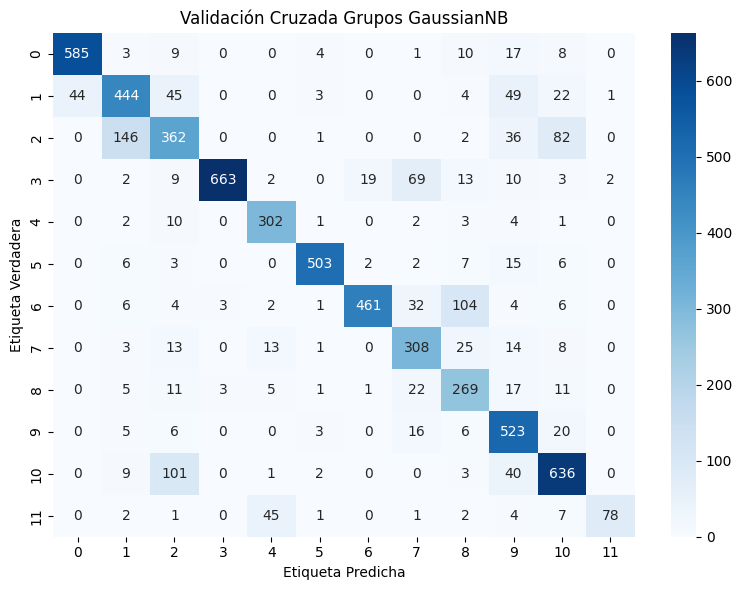

In [40]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
n_splits = pamap_features["subject_id"].nunique()

nb_loso_results = pipelinear_loso(
    model=nb,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Regresión LOSO

Puntuaciones (F1-macro):
  0.82185  0.76622  0.43342  0.79840  0.66939
  0.86160  0.86493  0.72714

Estadísticas de F1-macro:
Media:       0.74287
Mediana:     0.78231
Desvío:      0.13241
Mínimo:      0.43342
Máximo:      0.86493

Tiempos de entrenamiento (s):
  1.31116  1.46395  1.06932  1.36501  1.28172
  1.62235  1.71261  1.58190

Estadísticas de tiempos:
Media:       1.42600
Mediana:     1.41448
Desvío:      0.19729
Mínimo:      1.06932
Máximo:      1.71261


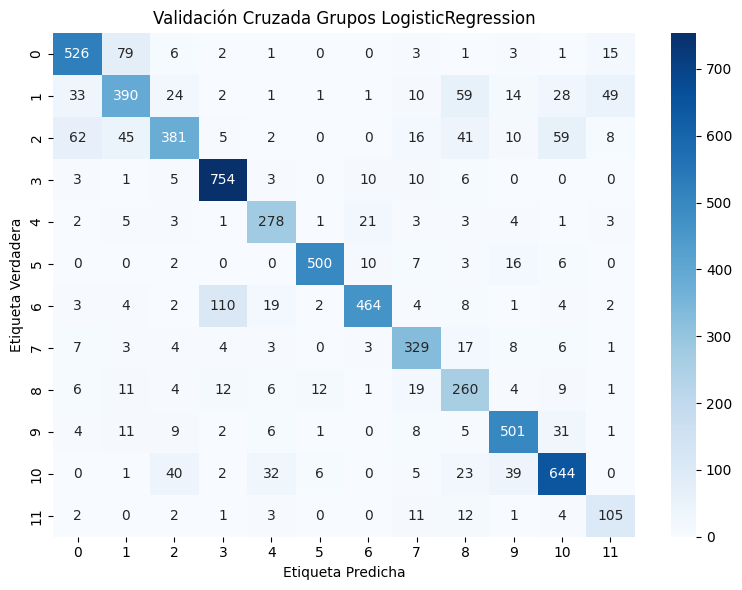

In [41]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# 4) Número de pliegues = número de grupos únicos
n_splits = pamap_features["subject_id"].nunique()

# 5) Llamada a la función
lr_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Perceptron LOSO

Puntuaciones (F1-macro):
  0.82588  0.65311  0.49475  0.77700  0.64931
  0.86067  0.85994  0.65011

Estadísticas de F1-macro:
Media:       0.72135
Mediana:     0.71505
Desvío:      0.12192
Mínimo:      0.49475
Máximo:      0.86067

Tiempos de entrenamiento (s):
  0.98903  1.16637  1.18237  1.30907  1.25149
  0.99661  1.31620  1.13646

Estadísticas de tiempos:
Media:       1.16845
Mediana:     1.17437
Desvío:      0.11803
Mínimo:      0.98903
Máximo:      1.31620


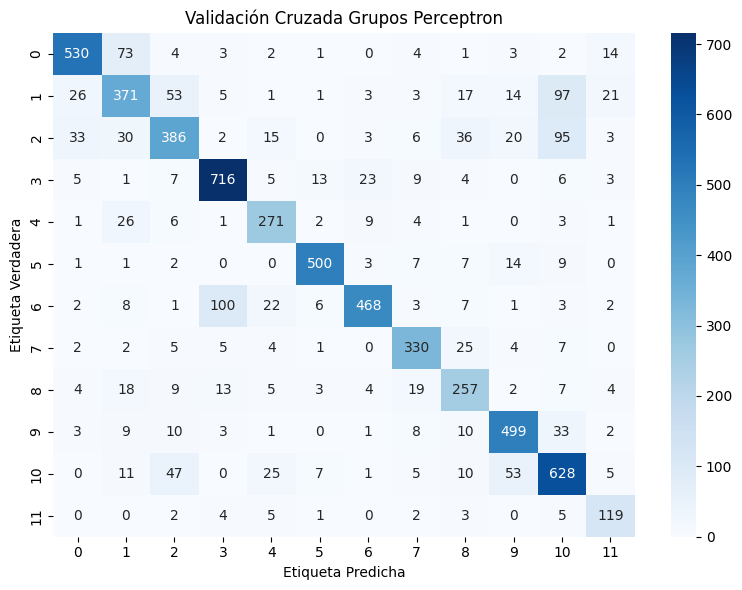

In [42]:
from sklearn.linear_model import Perceptron
model = Perceptron()

# 4) Número de pliegues = número de grupos únicos
n_splits = pamap_features["subject_id"].nunique()

# 5) Llamada a la función
mlp_loso = pipelinear_loso(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Random Forest LOSO

Puntuaciones (F1-macro):
  0.92282  0.88431  0.72218  0.89641  0.72175
  0.86348  0.92201  0.83448

Estadísticas de F1-macro:
Media:       0.84593
Mediana:     0.87389
Desvío:      0.07656
Mínimo:      0.72175
Máximo:      0.92282

Tiempos de entrenamiento (s):
  10.05956  10.06178  10.26805  10.38593  10.72124
  10.43042  10.56806  10.39771

Estadísticas de tiempos:
Media:       10.36159
Mediana:     10.39182
Desvío:      0.21462
Mínimo:      10.05956
Máximo:      10.72124


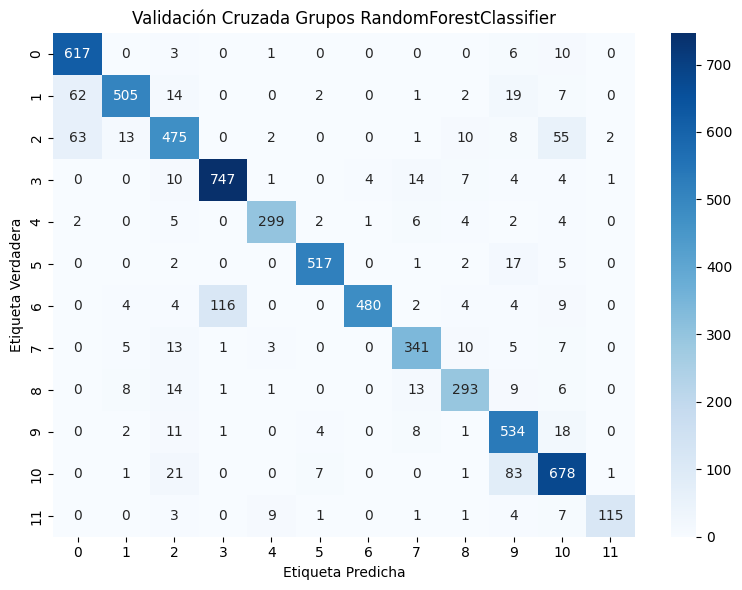

In [43]:
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

# 4) Número de pliegues = número de grupos únicos
n_splits = pamap_features["subject_id"].nunique()

# 5) Llamada a la función
rf_loso = pipelinear_loso(
    model=rf,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Voting LOSO

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso_pca_results = pipeline_kernel_pca(eclf, X, y)

## AdaBoost

Puntuaciones (F1-macro):
  0.74572  0.56263  0.52226  0.83394  0.65454
  0.85410  0.79618  0.87134

Estadísticas de F1-macro:
Media:       0.73009
Mediana:     0.77095
Desvío:      0.12633
Mínimo:      0.52226
Máximo:      0.87134

Tiempos de entrenamiento (s):
  88.45988  88.62054  89.01107  90.69656  90.86806
  89.01643  90.12925  88.86823

Estadísticas de tiempos:
Media:       89.45875
Mediana:     89.01375
Desvío:      0.89534
Mínimo:      88.45988
Máximo:      90.86806


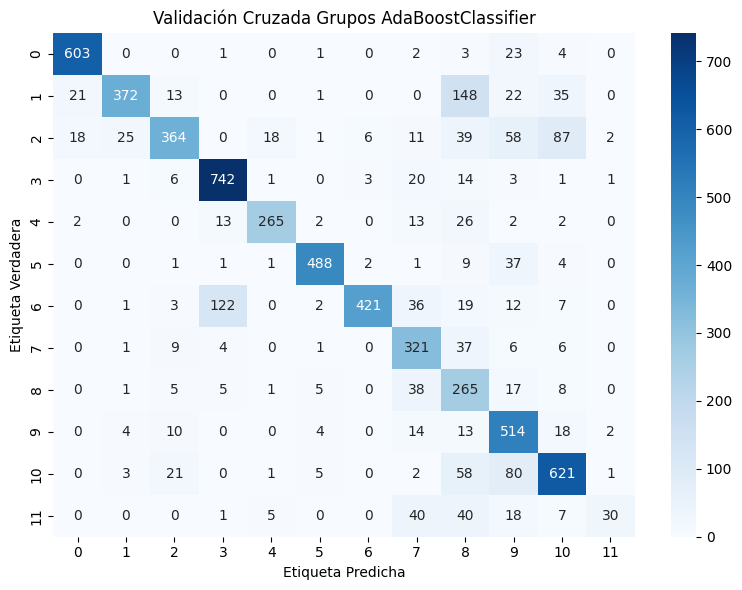

In [44]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

# 4) Número de pliegues = número de grupos únicos
n_splits = pamap_features["subject_id"].nunique()

# 5) Llamada a la función
rf_loso = pipelinear_loso(
    model=ada,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Comparación de algoritmos

In [34]:
import pandas as pd
import numpy as np

def compute_metrics(classifier_results, agg_func=np.mean):
    f1s, accs, precs, recalls = [], [], [], []

    for fold in classifier_results[2]:
        f1s.append(fold["f1_macro"])
        accs.append(fold["accuracy"])
        precs.append(fold["precision_macro"])
        recalls.append(fold["recall_macro"])

    metrics = {
        "f1_macro": agg_func(f1s),
        "accuracy": agg_func(accs),
        "precision_macro": agg_func(precs),
        "recall_macro": agg_func(recalls)
    }
    return metrics

# Ejemplo de uso
nb_mean_metrics = compute_metrics(nb_loso_results)
lr_mean_metrics = compute_metrics(lr_loso_results)
rf_mean_metrics = compute_metrics(rf_loso_results)
percep_mean_metrics = compute_metrics(percep_loso_results)
vc_mean_metrics = compute_metrics(eclf_loso_results)
ada_mean_metrics = compute_metrics(ada_loso_results)

# Crear un diccionario con los resultados
all_metrics = {
    "Naive Bayes": nb_mean_metrics,
    "Logistic Regression": lr_mean_metrics,
    "Random Forest": rf_mean_metrics,
    "Perceptron": percep_mean_metrics, 
    "Voting": vc_mean_metrics,
    "Adaboost": vc_mean_metrics
}

# Crear el DataFrame
df_metrics = pd.DataFrame.from_dict(all_metrics, orient="index")

# Imprimir el DataFrame
df_metrics.style.format(precision=5)

NameError: name 'lr_loso_results' is not defined

# LOSO PCA

In [31]:
import time
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
import numpy as np

# Assuming your dataframe has 'subject_id' column
X = pamap_features.drop(columns=['activity', 'subject_id']).values  
y = pamap_features['activity'].values
groups = pamap_features['subject_id'].values  # This will be used for LOSO

le = LabelEncoder()
y_encoded = le.fit_transform(y)

def execute_pipeline_loso_pca(model, X, y, groups):
    pca = PCA(n_components=0.95)
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler()
    
    pipe = make_pipeline(scaler, smote, pca, model)  # Note: Scaling before SMOTE is generally better

    logo = LeaveOneGroupOut()
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,  # Important: pass the groups parameter
        cv=logo,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1  # Use all available cores
    )
    
    all_scores = []
    for i in range(len(np.unique(groups))):  # Number of unique subjects
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)
        
    scores = cv_results["test_f1_macro"]
    times = cv_results["fit_time"]
    print_metrics(cv_results)

    return scores, times, all_scores

In [35]:
import os
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate, GroupKFold, cross_val_predict
from sklearn.metrics import (
    make_scorer, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Para que el texto sea seleccionable en SVG
matplotlib.rcParams['svg.fonttype'] = 'none'

def pipelinear_loso_pca(model, X, y, groups, n_splits=8):
    """
    Ajusta un pipeline (escalador + PCA al 95% de varianza + modelo)
    con CV por grupos (GroupKFold para leave-one-subject-out sobre 8 sujetos).
    X: features, y: etiquetas, groups: vector de grupos.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro
    (con zero_division=0), imprime todo en español, y dibuja/exporta la
    matriz de confusión out-of-fold en PNG (1080p, 4K) y SVG.
    El archivo se guarda en resultados_dsaa/crossval_groups_pca/
    con nombre "Validación Cruzada Grupos PCA {NombreDelClasificador}".
    """
    # 0) Codificación de etiquetas si vienen como texto
    if y.dtype == object or y.dtype.name == 'category':
        le = LabelEncoder()
        y_enc = le.fit_transform(y)
        etiquetas = le.classes_
    else:
        y_enc = y
        etiquetas = np.unique(y)

    # ----------------------------------------------------
    # → Cálculo de componentes antes/después de PCA al 95% 
    # ----------------------------------------------------
    scaler_temp = StandardScaler()
    X_scaled = scaler_temp.fit_transform(X)
    pca_temp = PCA(n_components=0.95)
    pca_temp.fit(X_scaled)
    n_before = X.shape[1]
    n_after  = pca_temp.n_components_
    print(f"Features originales: {n_before}")
    print(f"Features tras PCA (95% varianza): {n_after}\n")

    # 1) Scorers
    precision_zd = make_scorer(precision_score, average='macro', zero_division=0)
    recall_zd    = make_scorer(recall_score,    average='macro', zero_division=0)
    f1_zd        = make_scorer(f1_score,        average='macro', zero_division=0)
    accuracy     = 'accuracy'

    # 2) Pipeline + PCA + GroupKFold
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=0.95),
        model
    )
    cv = GroupKFold(n_splits=n_splits)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y_enc, groups=groups,
        cv=cv,
        scoring={
            "f1_macro":        f1_zd,
            "accuracy":        accuracy,
            "precision_macro": precision_zd,
            "recall_macro":    recall_zd
        },
        return_train_score=False,
        n_jobs=-1
    )

    # 3) Extraer métricas
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]
    all_scores = [
        {
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i],
        }
        for i in range(n_splits)
    ]

    # 4) Estadísticos
    def stats_arr(arr):
        return {
            "Media":    np.mean(arr),
            "Mediana":  np.median(arr),
            "Desvío":   np.std(arr),
            "Mínimo":   np.min(arr),
            "Máximo":   np.max(arr),
        }
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 5) Impresión de métricas (5 decimales)
    print("Puntuaciones (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.5f}" for s in scores[i:i+5]))
    print("\nEstadísticas de F1-macro:")
    for k, v in stats_scores.items():
        print(f"{k + ':':<12} {v:.5f}")
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.5f}" for t in times[i:i+5]))
    print("\nEstadísticas de tiempos:")
    for k, v in stats_times.items():
        print(f"{k + ':':<12} {v:.5f}")

    # 6) Predicciones out-of-fold y matriz de confusión
    y_pred = cross_val_predict(
        pipe, X, y_enc,
        groups=groups,
        cv=cv,
        n_jobs=-1
    )
    cm = confusion_matrix(y_enc, y_pred)

    # 7) Carpeta de salida
    output_folder = os.path.join("resultados_dsaa", "crossval_groups_pca")
    os.makedirs(output_folder, exist_ok=True)

    # 8) Dibujar matriz de confusión en español
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=etiquetas, yticklabels=etiquetas, ax=ax
    )
    ax.set_xlabel('Etiqueta Predicha')
    ax.set_ylabel('Etiqueta Verdadera')
    ax.set_title(f'Validación Cruzada Grupos PCA {model.__class__.__name__}')
    plt.tight_layout()
    plt.show()

    # 9) Guardar en varios formatos
    base = f"Validación Cruzada Grupos PCA {model.__class__.__name__}"
    fig.savefig(os.path.join(output_folder, f"{base}_1080p.png"), dpi=192, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}_4k.png"),   dpi=384, bbox_inches='tight')
    fig.savefig(os.path.join(output_folder, f"{base}.svg"),              bbox_inches='tight')

    return scores, times, all_scores

## NB LOSO (PCA)

Features originales: 144
Features tras PCA (95% varianza): 63

Puntuaciones (F1-macro):
  0.80035  0.73036  0.45083  0.76767  0.55648
  0.74518  0.73268  0.65686

Estadísticas de F1-macro:
Media:       0.68005
Mediana:     0.73152
Desvío:      0.11183
Mínimo:      0.45083
Máximo:      0.80035

Tiempos de entrenamiento (s):
  0.04186  0.07763  0.04775  0.04651  0.04310
  0.03734  0.04152  0.03562

Estadísticas de tiempos:
Media:       0.04642
Mediana:     0.04248
Desvío:      0.01241
Mínimo:      0.03562
Máximo:      0.07763


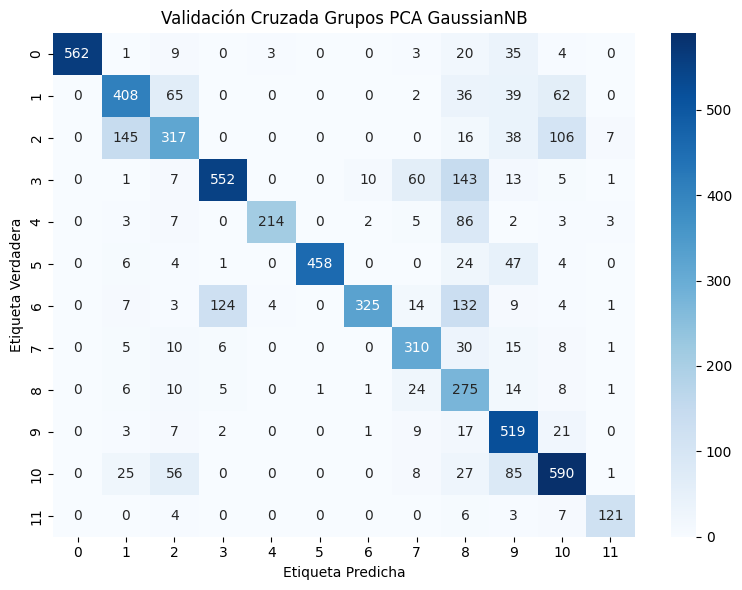

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# 1) Separar features, target y grupos
#X      = examples.drop(columns=["activity", "person_id"])
#y      = examples["activity"]
#groups = examples["person_id"]

X = pamap_features.drop(columns=['activity', 'subject_id'])
y = pamap_features['activity']
groups = pamap_features['subject_id']  # This will be used for LOSO

# 2) Encoding de y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3) Definir el modelo
model = GaussianNB()

# 4) Número de pliegues = número de grupos únicos
n_splits = pamap_features["subject_id"].nunique()

# 5) Llamada a la función
nb_loso_pca = pipelinear_loso_pca(
    model=model,
    X=X,                # tu DataFrame de features
    y=y_encoded,        # etiquetas codificadas
    groups=groups,      # person_id como grupos
    n_splits=n_splits   # ej. 8 personas → 8 folds
)

## Regresión LOSO (PCA)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_loso_pca_results = execute_pipeline_loso_pca(lr, X, y_encoded)

## Perceptron LOSO (PCA)

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_loso_pca_results = execute_pipeline_loso_pca(perceptron, X, y_encoded)

## Random Forest LOSO (PCA)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_loso_pca_results = execute_pipeline_loso_pca(rf, X, y_encoded)

## Voting LOSO (PCA)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso_pca_kernell_results = execute_pipeline_loso_pca(eclf, X, y)

## AdaBoost (PCA)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_loso_pca_results = execute_pipeline_loso_pca(ada, X, y_encoded)

# Pruebas LOSO PCA

## Comparativo PCA VS NOPCA

In [ ]:
import numpy as np
import pandas as pd

# Construimos el DataFrame usando la mediana, con nombres de columna limpios
performance_comparison_PCA = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.median(nb_loso_results[0]),
        "Con PCA": np.median(nb_loso_pca_results[0])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.median(lr_loso_results[0]),
        "Con PCA": np.median(lr_loso_pca_results[0])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.median(rf_loso_results[0]),
        "Con PCA": np.median(rf_loso_pca_results[0])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.median(percep_loso_results[0]),
        "Con PCA": np.median(percep_losopca_results[0])
    },
    {
        "Clasificador": "Voting",
        "Sin PCA": np.median(voting_loso_results[0]),
        "Con PCA": np.median(voting_loso_pca_results[0])
    }
])

performance_comparison_PCA.set_index("Clasificador", inplace=True)
performance_comparison_PCA

## Wilkoxon

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_loso_results[0]),        np.array(nb_loso_pca_results[0])),
    "Regresión Logística":           (np.array(lr_loso_results[0]),        np.array(lr_loso_pca_results[0])),
    "Bosques Aleatorios":            (np.array(rf_loso_results[0]),        np.array(rf_loso_pca_results[0])),
    "Perceptrón":                    (np.array(percep_loso_results[0]),    np.array(percep_loso_pca_results[0])),
    "Voting Classifier":             (np.array(eclf_loso_results[0]),    np.array(eclf_loso_pca_results[0])),
    "Adaboost":             (np.array(ada_results_1[0]),    np.array(ada_pca_results[0]))
}


alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# Tu diccionario
scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_loso_results[0]),        np.array(nb_loso_pca_results[0])),
    "Regresión Logística":           (np.array(lr_loso_results[0]),        np.array(lr_loso_pca_results[0])),
    "Bosques Aleatorios":            (np.array(rf_loso_results[0]),        np.array(rf_loso_pca_results[0])),
    "Perceptrón":                    (np.array(percep_loso_results[0]),    np.array(percep_loso_pca_results[0])),
    "Voting Classifier":             (np.array(eclf_loso_results[0]),    np.array(eclf_loso_pca_results[0])),
    "Adaboost":             (np.array(ada_results_1[0]),    np.array(ada_pca_results[0]))
}


# Combinar todos los resultados en dos arrays
f1_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
f1_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert f1_sin_pca.shape == f1_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(f1_sin_pca, f1_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

## Pruebas de tiempo

In [ ]:
import numpy as np
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_loso_results[1]),
        "Con PCA": np.mean(nb_loso_pca_results[1])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_loso_results[1]),
        "Con PCA": np.mean(lr_loso_pca_results[1])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_loso_results[1]),
        "Con PCA": np.mean(rf_loso_pca_results[1])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_loso_results[1]),
        "Con PCA": np.mean(percep_loso_pca_results[1])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.median(eclf_loso_results[1]),
        "Con PCA": np.median(eclf_loso_pca_results[1])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.median(ada_loso_results[1]),
        "Con PCA": np.median(ada_loso_pca_results[1])
    }
])


df.set_index("Clasificador", inplace=True)

df

In [ ]:
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_loso_results[1]),
        "Con PCA": np.mean(nb_loso_pca_results[1])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_loso_results[1]),
        "Con PCA": np.mean(lr_loso_pca_results[1])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_loso_results[1]),
        "Con PCA": np.mean(rf_loso_pca_results[1])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_loso_results[1]),
        "Con PCA": np.mean(percep_loso_pca_results[1])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.median(eclf_loso_results[1]),
        "Con PCA": np.median(eclf_loso_pca_results[1])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.median(ada_loso_results[1]),
        "Con PCA": np.median(ada_loso_pca_results[1])
    }
])



df.set_index("Clasificador", inplace=True)

df

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_loso_results[metric_idx]),              np.array(nb_loso_pca_results[metric_idx])),
    "Regresión Logística":           (np.array(lr_loso_results[metric_idx]),              np.array(lr_loso_pca_results[metric_idx])),
    "Bosques Aleatorios":            (np.array(rf_loso_results[metric_idx]),              np.array(rf_loso_pca_results[metric_idx])),
    "Perceptrón":                    (np.array(percep_loso_results[metric_idx]),          np.array(percep_loso_pca_results[metric_idx])),
    "Voting":                        (np.array(eclf_loso_results[metric_idx]),            np.array(eclf_loso_pca_results[metric_idx])),
    "Adaboost":                      (np.array(ada_loso_results[metric_idx]),             np.array(ada_loso_pca_results[metric_idx])),
}


alpha = 0.05
rows = []

for clf, (sin_pca, con_pca) in scores_dict.items():
    # Wilcoxon signed‐rank test (pareado)
    stat, p = wilcoxon(sin_pca, con_pca, alternative="two-sided")
    
    rows.append({
        "Clasificador":  clf,
        "Sin PCA":       np.median(sin_pca),
        "Con PCA":       np.median(con_pca),
        "p-value":       p,
        "Significativo": "Sí" if p < alpha else "No"
    })

# Crear DataFrame
results_table = pd.DataFrame(rows).set_index("Clasificador")

# Formatear numéricos a 4 decimales
for col in ["Sin PCA", "Con PCA"]:
    results_table[col] = results_table[col].map(lambda x: f"{x:.4f}")
results_table["p-value"] = results_table["p-value"].map(lambda x: f"{x:.4f}")

results_table

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

TIEMPO = 1
metric_idx = TIEMPO

scores_dict = {
    "Bayes Ingenuo":                 (np.array(nb_loso_results[metric_idx]),              np.array(nb_loso_pca_results[metric_idx])),
    "Regresión Logística":           (np.array(lr_loso_results[metric_idx]),              np.array(lr_loso_pca_results[metric_idx])),
    "Bosques Aleatorios":            (np.array(rf_loso_results[metric_idx]),              np.array(rf_loso_pca_results[metric_idx])),
    "Perceptrón":                    (np.array(percep_loso_results[metric_idx]),          np.array(percep_loso_pca_results[metric_idx])),
    "Voting":                        (np.array(eclf_loso_results[metric_idx]),            np.array(eclf_loso_pca_results[metric_idx])),
    "Adaboost":                      (np.array(ada_loso_results[metric_idx]),             np.array(ada_loso_pca_results[metric_idx])),
}

# Combinar todos los resultados en dos arrays
tiempo_sin_pca = np.concatenate([v[0] for v in scores_dict.values()])
tiempo_con_pca = np.concatenate([v[1] for v in scores_dict.values()])

# Confirmar que los pares están alineados
assert tiempo_sin_pca.shape == tiempo_con_pca.shape

# Prueba de Wilcoxon para muestras pareadas
stat, p = wilcoxon(tiempo_sin_pca, tiempo_con_pca)

# Imprimir resultados
print(f"Estadístico de Wilcoxon: {stat:.4f}")
print(f"Valor-p: {p:.4f}")

if p < 0.05:
    print("✅ Hay diferencia estadísticamente significativa con el uso de PCA.")
else:
    print("❌ No hay diferencia estadísticamente significativa con el uso de PCA.")

# LOSO PCA (Kernel)

In [ ]:
import time
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
import numpy as np

# Assuming your dataframe has 'subject_id' column
X = pamap_features.drop(columns=['activity', 'subject_id']).values  
y = pamap_features['activity'].values
groups = pamap_features['subject_id'].values  # This will be used for LOSO

le = LabelEncoder()
y_encoded = le.fit_transform(y)

def execute_pipeline_loso_pca_kernel(model, X, y, groups):
    pca = KernelPCA(n_components=85, kernel=kernel)
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler()
    
    pipe = make_pipeline(scaler, smote, pca, model)  # Note: Scaling before SMOTE is generally better

    logo = LeaveOneGroupOut()
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,  # Important: pass the groups parameter
        cv=logo,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1  # Use all available cores
    )
    
    all_scores = []
    for i in range(len(np.unique(groups))):  # Number of unique subjects
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)
        
    scores = cv_results["test_f1_macro"]
    times = cv_results["fit_time"]
    print_metrics(cv_results)

    return scores, times, all_scores

## NB LOSO (PCA)

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_loso_pca_kernel_results = execute_pipeline_loso_pca_kernel(nb, X, y_encoded, n_components=componentes)

Original feature count: 144


## Regresión LOSO (PCA)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_loso_pca_kernel_results = execute_pipeline_loso_pca_kernel(lr, X, y_encoded)

## Perceptron LOSO (PCA)

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_loso_pca_kernel_results = execute_pipeline_loso_pca_kernel(perceptron, X, y_encoded)

## Random Forest LOSO (PCA)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_loso_pca_kernel_results = execute_pipeline_loso_pca_kernel(rf, X, y_encoded)

## Voting LOSO (PCA)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.classifier import EnsembleVoteClassifier
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# 1) Clasificadores base (cada uno para su SFS)
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(random_state=1, n_jobs=1)
clf3 = GaussianNB() 

# 2) SequentialFeatureSelector (k=3, scoring interno f1_macro, cv=5) 
sfs1 = SequentialFeatureSelector(clf1, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs2 = SequentialFeatureSelector(clf2, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)
sfs3 = SequentialFeatureSelector(clf3, k_features=3, forward=True,
          floating=False, scoring='f1_macro', cv=5, n_jobs=-1)

# 3) Pipelines individuales: SFS → Clasificador
pipe_lr = Pipeline([('sfs', sfs1),
                    ('lr', LogisticRegression(random_state=1, max_iter=1000))])
pipe_rf = Pipeline([('sfs', sfs2), ('rf', clf2)])
pipe_nb = Pipeline([('sfs', sfs3), ('nb', clf3)])

eclf = EnsembleVoteClassifier(clfs=[pipe_lr, pipe_rf, pipe_nb], voting='soft')

eclf_loso_pca_kernell_results = execute_pipeline_loso_pca_kernel(eclf, X, y)

## AdaBoost (PCA)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

base_estimator = DecisionTreeClassifier(max_depth=4)
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)

ada_loso_pca_kernel_results = execute_pipeline_loso_pca_kernel(ada, X, y_encoded)

# Pruebas LOSOPCA kernel

In [ ]:
import numpy as np
import pandas as pd

F1_SCORE= 0

metric_index = F1_SCORE

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_loso_results[metric_index]),
        "Con PCA": np.mean(nb_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(nb_loso_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_loso_results[metric_index]),
        "Con PCA": np.mean(lr_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(lr_loso_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_loso_results[metric_index]),
        "Con PCA": np.mean(rf_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(rf_loso_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_loso_results[metric_index]),
        "Con PCA": np.mean(percep_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(percep_loso_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Voting Classifier",
        "Sin PCA": np.mean(eclf_loso_results[metric_index]),
        "Con PCA": np.mean(eclf_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(eclf_loso_pca_kernell_results[metric_index])
    },
    {
        "Clasificador": "Adaboost",
        "Sin PCA": np.mean(eclf_loso_results[metric_index]),
        "Con PCA": np.mean(eclf_loso_pca_results[metric_index]),
        "PCA Kernell": np.mean(eclf_loso_pca_kernell_results[metric_index])
    }
])


df.set_index("Clasificador", inplace=True)

df

In [ ]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

# Crear matriz x: cada fila es un método, cada columna un fold
x = np.array([
    nb_loso_results[metric_index],                # x[0]
    nb_loso_pca_results[metric_index],            # x[1]
    nb_loso_pca_kernell_results[metric_index],    # x[2]

    lr_results[metric_index],                # x[3]
    lr_loso_pca_results[metric_index],            # x[4]
    lr_loso_pca_kernell_results[metric_index],    # x[5]

    rf_loso_results[metric_index],                # x[6]
    rf_loso_pca_results[metric_index],            # x[7]
    rf_loso_pca_kernell_results[metric_index],    # x[8]

    percep_loso_results[metric_index],            # x[9]
    percep_loso_pca_results[metric_index],        # x[10]
    percep_loso_pca_kernell_results[metric_index],# x[11]
    
    eclf_loso_results[metric_index],               # x[12]
    eclf_loso_pca_results[metric_index],           # x[13]
    eclf_loso_pca_kernell_results[metric_index],   # x[14]

    ada_loso_results[metric_index],               # x[15]
    ada_loso_pca_results[metric_index],           # x[16]
    ada_loso_pca_kernell_results[metric_index],   # x[17]

    
])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "Voting - Sin PCA", 13: "Voting - PCA",     14: "Voting - PCA Kernel",
    15: "Adaboost - Sin PCA", 16: "Adaboost - PCA",     17: "Adaboost - PCA Kernel",
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13],x[14], x[15], x[16], x[17])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")

In [ ]:
import numpy as np
from scipy.stats import friedmanchisquare

# Índice de la métrica a comparar (ej: F1_SCORE = 0)
F1_SCORE = 0
metric_index = F1_SCORE

x = np.array([
    nb_loso_results[metric_index],                # x[0]
    nb_loso_pca_results[metric_index],            # x[1]
    nb_loso_pca_kernell_results[metric_index],    # x[2]

    lr_results[metric_index],                # x[3]
    lr_loso_pca_results[metric_index],            # x[4]
    lr_loso_pca_kernell_results[metric_index],    # x[5]

    rf_loso_results[metric_index],                # x[6]
    rf_loso_pca_results[metric_index],            # x[7]
    rf_loso_pca_kernell_results[metric_index],    # x[8]

    percep_loso_results[metric_index],            # x[9]
    percep_loso_pca_results[metric_index],        # x[10]
    percep_loso_pca_kernell_results[metric_index],# x[11]
    
    eclf_loso_results[metric_index],               # x[12]
    eclf_loso_pca_results[metric_index],           # x[13]
    eclf_loso_pca_kernell_results[metric_index],   # x[14]

    ada_loso_results[metric_index],               # x[15]
    ada_loso_pca_results[metric_index],           # x[16]
    ada_loso_pca_kernell_results[metric_index],   # x[17]

    
])

# Diccionario opcional para mapear índices a nombres de métodos
metodos = {
    0: "NB - Sin PCA",       1: "NB - PCA",           2: "NB - PCA Kernel",
    3: "LR - Sin PCA",       4: "LR - PCA",           5: "LR - PCA Kernel",
    6: "RF - Sin PCA",       7: "RF - PCA",           8: "RF - PCA Kernel",
    9: "Perceptrón - Sin PCA", 10: "Perceptrón - PCA", 11: "Perceptrón - PCA Kernel",
    12: "Voting - Sin PCA", 13: "Voting - PCA",     14: "Voting - PCA Kernel",
    15: "Adaboost - Sin PCA", 16: "Adaboost - PCA",     17: "Adaboost - PCA Kernel",
}

# Aplicar test de Friedman con los 15 métodos
res = friedmanchisquare(x[0], x[1], x[2], x[3], x[4], x[5],
                        x[6], x[7], x[8], x[9], x[10], x[11],
                        x[12], x[13],x[14], x[15], x[16], x[17])

# Mostrar resultados
print("=== Test de Friedman ===")
print(f"Estadístico: {res.statistic:.4f}")
print(f"p-value:     {res.pvalue:.4f}")
if res.pvalue < 0.05:
    print("→ Hay diferencias significativas entre los métodos")
else:
    print("→ No hay diferencias significativas")